In [1]:
# Mobility Heatmap Analysis Notebook
import pandas as pd
import numpy as np
import geopandas as gpd
import pickle as pkl
from shapely.geometry import Point, box
from geolib import geohash as geolib
import h3
import shapely.geometry as geometry
import os


# --------------------------------------------------------
# Parameters
# --------------------------------------------------------
keep_only_ch = True # Whether to keep only data in Switzerland (based on geohashes)


# -------------------------------------------------------
# Load Data
# -------------------------------------------------------

paths = pd.read_csv("data/all_paths_128.csv", sep=";")
movements = pd.read_csv("data/all_movements_146.csv", sep=";")
steps = pd.read_csv("data/all_steps_3.csv", sep=";")
lifestyles = pd.read_csv("data/lifestyles.csv", sep=",")

# -------------------------------------------------------
# Load / init cache
# -------------------------------------------------------
try:
    geohashes_cache = pkl.load(open("./geohashes_to_coords.pkl", "rb"))
except FileNotFoundError:
    geohashes_cache = {}

# Read geohashes to coordinates mapping (dataframe with columns: geohash, latitude, longitude)
geo_to_coords = pd.read_pickle('geohashes_to_coords.pkl')

# Function to complete geo_to_coords with missing geohashes
def complete_geo_to_coords(geo_to_coords, geohashes):
    missing_geohashes = set(geohashes) - set(geo_to_coords['geohash'])
    new_rows = []
    for gh in missing_geohashes:
        try:
            lat, lon = geolib.decode(gh)
            new_rows.append({'geohash': gh, 'latitude': lat, 'longitude': lon})
        except Exception as e:
            print(f"Error decoding geohash {gh}: {e}")
    if new_rows:
        geo_to_coords = pd.concat([geo_to_coords, pd.DataFrame(new_rows)], ignore_index=True)
        geo_to_coords.to_pickle('geohashes_to_coords.pkl') # Save to file
    return geo_to_coords

In [2]:
import rasterio

def polygon_vertex_centroid_points(poly):
    """
    Returns list of (x,y) = (lon,lat) points: polygon exterior vertices + centroid.
    """
    coords = list(poly.exterior.coords)[:-1]  # drop closing duplicate
    c = poly.centroid
    coords.append((c.x, c.y))                 # (lon,lat)
    return coords

def add_elevation_to_gdf(gdf, dem_path):
    """
    Adds average elevation to each polygon in gdf by sampling DEM at polygon vertices + centroid.
    Returns new GeoDataFrame with 'avg_elevation' column.
    """
    all_points = []
    row_slices = []  # (start, end) indices into all_points

    # Open DEM first so we can safely reproject if needed
    with rasterio.open(dem_path) as src:
        # Reproject geometries to DEM CRS if needed
        gdf_src = gdf.to_crs(src.crs) if (gdf.crs != src.crs) else gdf

        for poly in gdf_src.geometry:
            pts = polygon_vertex_centroid_points(poly)  # always (lon,lat) in EPSG:4326; (x,y) in general CRS
            start = len(all_points)
            all_points.extend(pts)
            row_slices.append((start, len(all_points)))

        # Sample raster at all points
        elev = np.array([v[0] for v in src.sample(all_points)], dtype="float64")

        # Handle nodata if present
        if src.nodata is not None:
            elev[elev == src.nodata] = np.nan
        else:
            # SwissDEM behavior in your file: 0 means "outside coverage"
            elev[elev == 0] = np.nan

    # Mean elevation per row (ignore NaNs)
    means = [np.nanmean(elev[s:e]) for (s, e) in row_slices]

    out = gdf.copy()
    out["avg_elevation"] = means

    # Keep only rows with valid elevation
    out = out[~np.isnan(out["avg_elevation"])]

    return out

# Add elevation using a single coordinate
def get_elevation_at_point(lon, lat, dem):
    coords = [(lon, lat)]
    for val in dem.sample(coords):
        elevation = val[0]
        if elevation == dem.nodata:
            return np.nan
        return elevation
    return np.nan

In [3]:
# Geohashes in switzerland
swiss_geohashes = [f"u0{c}" for c in "kmqrhjnp"]
# Keep only bern
#swiss_geohashes = ["u0m"]
# Keep only zurich-winterthur
#swiss_geohashes = ["u0q"]

# Translate selected modes of transport to corresponding actual transport modes
def translate_mot(mot):
    if mot == "CAR" or mot == "ELECTRIC_CAR" or mot == "HYBRID_CAR" or mot == "MOTORBIKE":
        return "Car"
    elif mot == "TRAIN":
        return "Train"
    elif mot == "WALKING":
        return "Walking"
    elif mot == "ON_BICYCLE" or mot == "ELECTRIC_BIKE" or mot == "SCOOTER" or mot == "ELECTRIC_SCOOTER":
        return "Bicycle"
    elif mot == "BUS" or mot == "ELECTRIC_BUS" or mot == "COACH":
        return "Bus"
    elif mot == "TRAM":
        return "Tram"
    elif mot == "PLANE":
        return "Plane"
    elif mot == "BOAT" or mot == "BOAT_NO_ENGINE":
        return "Boat"
    else:
        return mot

In [4]:
# Get canton boundaries
# Load cantonal boundaries
gpkg = "data/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg"

# selected layer: cantonal boundaries
lyr = "tlm_kantonsgebiet"

canton_gdf = gpd.read_file(gpkg, layer=lyr)

In [5]:
# Keep only max 7 characters of geohash for paths
paths['geohash'] = paths['geohash'].str.slice(0, 8)

In [6]:
# Keep only data in switzerland
if keep_only_ch:
    paths = paths[(paths['geohash'].str.startswith(tuple(swiss_geohashes)))]

    movements = movements[(movements['start_geohash'].str.startswith(tuple(swiss_geohashes)))]
    movements = movements[movements['end_geohash'].str.startswith(tuple(swiss_geohashes))]

# Translate mean of transport by simplifying (e.g., CAR, ELECTRIC_CAR, HYBRID_CAR -> CAR)
paths['mean_of_transport'] = paths['mode_of_transport'].apply(translate_mot)

movements['mean_of_transport'] = movements['mean_of_transport'].apply(translate_mot)
movements['original_mean_of_transport'] = movements['original_mean_of_transport'].apply(translate_mot)

In [7]:
combined_geohashes = set(movements['start_geohash']).union(set(movements['end_geohash'])).union(set(paths['geohash'].dropna()))
geo_to_coords = complete_geo_to_coords(geo_to_coords, combined_geohashes)

In [8]:
## Convert distance to int
movements['distance(m)'] = movements['distance(m)'].astype(int)

## Convert gCO2 to int
movements['gCO2'] = movements['gCO2'].astype(int)

In [9]:
# Convert start_time and end_time to datetime
movements["start_time"] = pd.to_datetime(movements["start_time"], errors="coerce")
movements["end_time"] = pd.to_datetime(movements["end_time"], errors="coerce")

movements["dow"] = movements["start_time"].dt.day_of_week
movements["is_weekend"] = movements["dow"].isin([5,6])

movements["date"] = movements["start_time"].dt.date

In [10]:
# See the lifestyles
lifestyles.head()

,participantid,lifestyle1,lifestyle2
0,4L5S1E,Eco-Friendly Nikki,Modest Billie
1,9U7Q9K,Eco-Friendly Nikki,Comfort-Oriented Gaby
2,8G2B2C,Eco-Friendly Nikki,Modest Billie
3,6F10L1F,Eco-Friendly Nikki,Modest Billie
4,10F11M1A,Eco-Friendly Nikki,Techie Tony


In [11]:
# Get movements length before filtering by lifestyles
print(f"Total movements before filtering by lifestyles: {len(movements)}")

Total movements before filtering by lifestyles: 42442


In [12]:
# Get the total number of unique users in the movements dataframe
total_users = movements['participant_id'].nunique()
print(f"Total unique users in movements: {total_users}")

Total unique users in movements: 115


In [13]:
# GEt number of participants that did at least 100 movements
participants_with_100_movements = movements['participant_id'].value_counts()
participants_with_100_movements = participants_with_100_movements[participants_with_100_movements >= 100]
num_participants_with_100_movements = len(participants_with_100_movements)
print(f"Number of participants with at least 100 movements: {num_participants_with_100_movements}")

Number of participants with at least 100 movements: 62


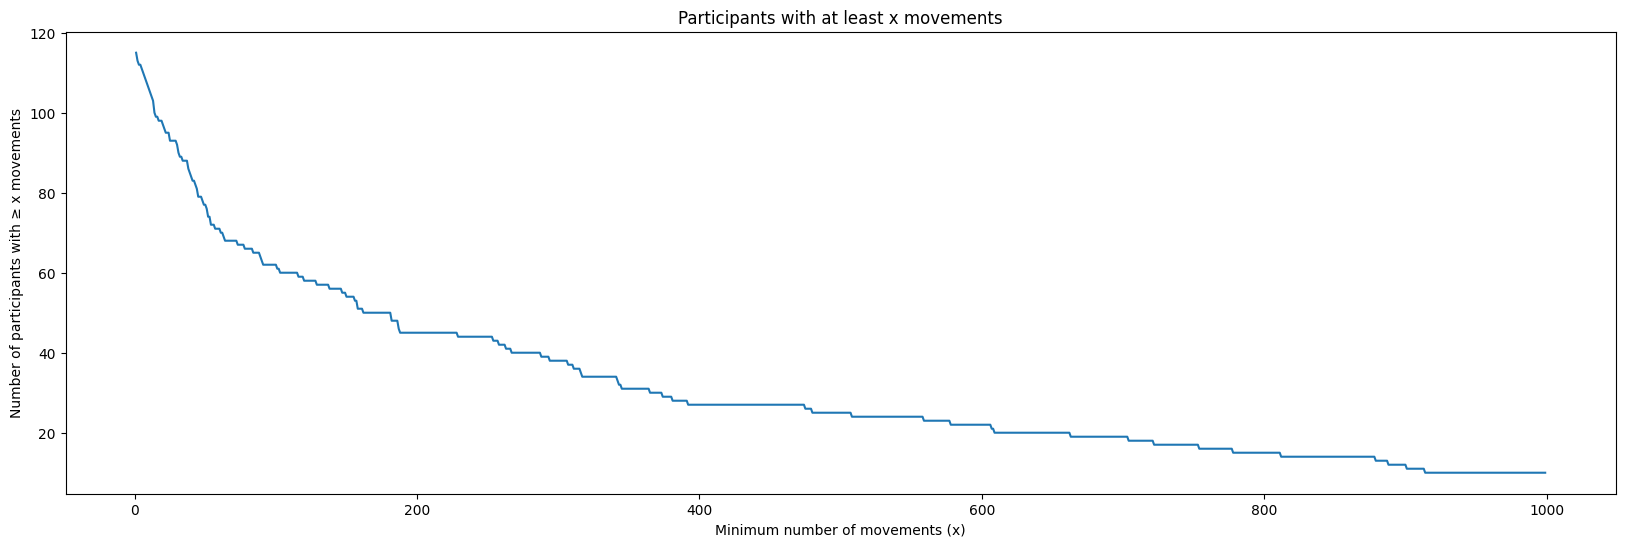

In [14]:
import matplotlib.pyplot as plt

# Count movements per participant
movement_counts = movements['participant_id'].value_counts()

# Sort counts descending
movement_counts = movement_counts.sort_values(ascending=False)

# For each possible threshold x
x_values = range(1, 1000)

participants_with_at_least_x = [
    (movement_counts >= x).sum() for x in x_values
]

plt.figure(figsize=(20, 6))
plt.plot(x_values, participants_with_at_least_x)
plt.xlabel("Minimum number of movements (x)")
plt.ylabel("Number of participants with ≥ x movements")
plt.title("Participants with at least x movements")
plt.show()

In [15]:
# Get date range of movements
min_date = movements["start_time"].min()
max_date = movements["start_time"].max()
print(f"Date range of movements: {min_date} to {max_date}")

Date range of movements: 2024-08-28 06:47:10+00:00 to 2026-06-01 08:10:59+00:00


In [16]:
# Keep only movements with participant_id in lifestyles
movements = movements[movements['participant_id'].isin(lifestyles['participantid'])]

In [17]:
# Get movements length after filtering by lifestyles
print(f"Total movements after filtering by lifestyles: {len(movements)}")

Total movements after filtering by lifestyles: 30017


In [18]:
### TODO: This is temporary!
# Keep only commuters
'''
movements = movements[movements["participant_id"].isin(['0L3S1J', '0Q1Q9Q', '10H7K1A', '10Z9B1H', '119817XU1', '11W4Y1H',
       '12W4H1U', '2E7B3M', '2F11GXA', '2L1M1R', '3B10M2A', '3H8WXK',
       '3K9V1H', '4C5PXH', '4F2ZXD', '4L5S1E', '4T11G3A', '5U3B1R',
       '5W2RXT', '5W2SXE', '6F10L1F', '6S5T1H', '6T2PXJ', '7C3E1I',
       '8B5V1C', '8F5P1K', '9B11R1G', '9B6T1M', '9M2KXX', '9P3WXJ'])]
'''

'\nmovements = movements[movements["participant_id"].isin([\'0L3S1J\', \'0Q1Q9Q\', \'10H7K1A\', \'10Z9B1H\', \'119817XU1\', \'11W4Y1H\',\n       \'12W4H1U\', \'2E7B3M\', \'2F11GXA\', \'2L1M1R\', \'3B10M2A\', \'3H8WXK\',\n       \'3K9V1H\', \'4C5PXH\', \'4F2ZXD\', \'4L5S1E\', \'4T11G3A\', \'5U3B1R\',\n       \'5W2RXT\', \'5W2SXE\', \'6F10L1F\', \'6S5T1H\', \'6T2PXJ\', \'7C3E1I\',\n       \'8B5V1C\', \'8F5P1K\', \'9B11R1G\', \'9B6T1M\', \'9M2KXX\', \'9P3WXJ\'])]\n'

In [19]:
# Number of unique participants in movements
print(f"Number of unique participants in movements: {movements['participant_id'].nunique()}")

Number of unique participants in movements: 46


In [20]:
movements.head()

,participant_id,start_time,end_time,start_geohash,end_geohash,distance(m),mean_of_transport,original_mean_of_transport,gCO2,is_power_saving,dow,is_weekend,date
4,4L5S1E,2024-09-03 16:23:18+00:00,2024-09-03 16:25:21+00:00,u0m709,u0m70d,570,Bicycle,Bicycle,3,False,1,False,2024-09-03
5,4L5S1E,2024-09-03 17:07:08+00:00,2024-09-03 17:17:04+00:00,u0m709,u0m70f,326,Walking,Walking,0,False,1,False,2024-09-03
6,4L5S1E,2024-09-03 17:17:05+00:00,2024-09-03 17:24:40+00:00,u0m70f,u0m716,1857,Bus,Bus,245,False,1,False,2024-09-03
18,119817XU1,2024-08-28 07:38:11+00:00,2024-08-28 07:42:14+00:00,u0qnpk,u0qnpk,254,Walking,Walking,0,False,2,False,2024-08-28
19,119817XU1,2024-08-28 07:42:15+00:00,2024-08-28 07:44:19+00:00,u0qnpk,u0qnps,598,Bicycle,Bicycle,6,False,2,False,2024-08-28


In [21]:
def fractional_hours(df, start_col="start_time", end_col="end_time"):
    """
    Returns a new DataFrame where each original row is expanded into one row per
    overlapping hour bin, with weight = fraction of that hour occupied.

    Assumes start_time/end_time are timezone-consistent pandas Timestamps.
    Handles trips crossing midnight.
    """
    out_rows = []

    for idx, row in df.iterrows():
        start = row[start_col]
        end = row[end_col]

        if pd.isna(start) or pd.isna(end) or end <= start:
            continue

        # Iterate hour bins from floor(start) to end
        cur = start.floor("h")
        while cur < end:
            bin_start = cur
            bin_end = cur + pd.Timedelta(hours=1)

            overlap_start = max(start, bin_start)
            overlap_end = min(end, bin_end)

            overlap_sec = (overlap_end - overlap_start).total_seconds()
            if overlap_sec > 0:
                new = row.to_dict()
                new["hour_of_day"] = int(bin_start.hour)
                new["weight"] = overlap_sec / 3600.0  # fraction of hour
                out_rows.append(new)

            cur = bin_end

    return pd.DataFrame(out_rows)


In [22]:
# Add corresponding lifestyle to movements
movements = movements.merge(lifestyles[['participantid', 'lifestyle1', 'lifestyle2']], left_on='participant_id', right_on='participantid', how='left')
movements.drop(columns=['participantid'], inplace=True)

In [23]:
movements.head()

,participant_id,start_time,end_time,start_geohash,end_geohash,distance(m),mean_of_transport,original_mean_of_transport,gCO2,is_power_saving,dow,is_weekend,date,lifestyle1,lifestyle2
0,4L5S1E,2024-09-03 16:23:18+00:00,2024-09-03 16:25:21+00:00,u0m709,u0m70d,570,Bicycle,Bicycle,3,False,1,False,2024-09-03,Eco-Friendly Nikki,Modest Billie
1,4L5S1E,2024-09-03 17:07:08+00:00,2024-09-03 17:17:04+00:00,u0m709,u0m70f,326,Walking,Walking,0,False,1,False,2024-09-03,Eco-Friendly Nikki,Modest Billie
2,4L5S1E,2024-09-03 17:17:05+00:00,2024-09-03 17:24:40+00:00,u0m70f,u0m716,1857,Bus,Bus,245,False,1,False,2024-09-03,Eco-Friendly Nikki,Modest Billie
3,119817XU1,2024-08-28 07:38:11+00:00,2024-08-28 07:42:14+00:00,u0qnpk,u0qnpk,254,Walking,Walking,0,False,2,False,2024-08-28,Eco-Friendly Nikki,Modest Billie
4,119817XU1,2024-08-28 07:42:15+00:00,2024-08-28 07:44:19+00:00,u0qnpk,u0qnps,598,Bicycle,Bicycle,6,False,2,False,2024-08-28,Eco-Friendly Nikki,Modest Billie


In [24]:
# Number of flights per lifestyle
flight_counts = movements[movements["mean_of_transport"] == "Plane"].groupby("lifestyle1")["participant_id"].nunique()
print("Number of participants who took at least one flight, by lifestyle:")
print(flight_counts)

Number of participants who took at least one flight, by lifestyle:
Series([], Name: participant_id, dtype: int64)


--- Permutation Tests: Total Daily gCO2 ---
Eco-Friendly Nikki: p=0.0182, diff (Weekend - Weekday)=1175.12 gCO2
Focused Francis: p=0.2500 (Not significant)
Modest Billie: p=0.9688 (Not significant)


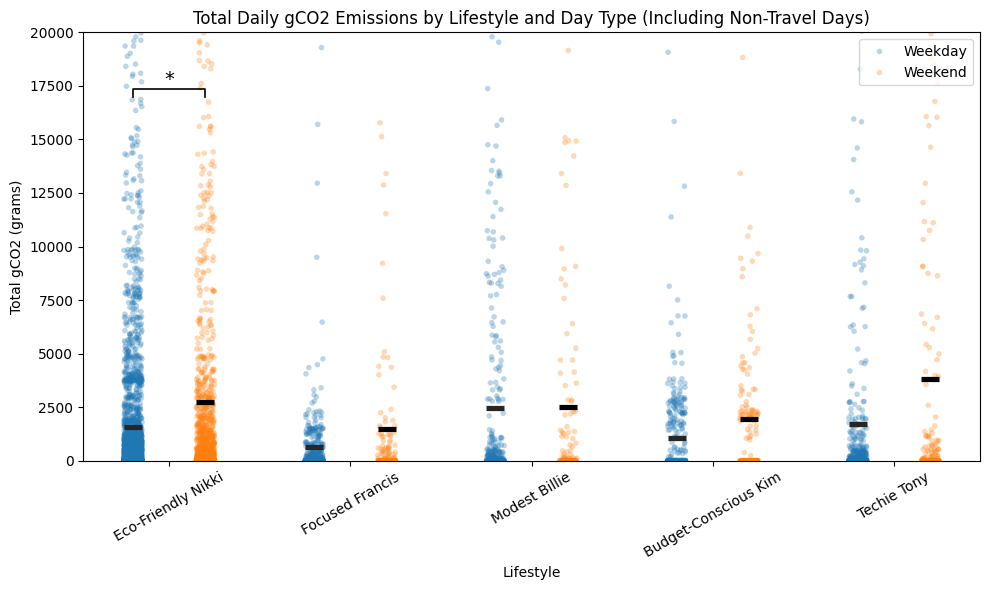

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import permutation_test

def diff_in_means(x, y, axis):
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)

# 1. Base filtering & initial aggregation
df = movements.copy()
df = df[~df["mean_of_transport"].isin(["Boat", "DETECTION_ERROR"])]
df = df[~((df["mean_of_transport"] == "Walking") & (df["distance(m)"] > 40000))]

df["date"] = pd.to_datetime(df["date"])

daily_total = df.groupby(["participant_id", "lifestyle1", "date"])["gCO2"].sum().reset_index()

# 2. Fill missing dates with 0 gCO2 per participant
complete_dates = daily_total.groupby(["participant_id", "lifestyle1"])["date"].apply(
    lambda x: pd.date_range(x.min(), x.max(), freq='D')
).explode().reset_index(name='date')

daily_total_filled = pd.merge(complete_dates, daily_total, on=["participant_id", "lifestyle1", "date"], how="left")
daily_total_filled["gCO2"] = daily_total_filled["gCO2"].fillna(0)
daily_total_filled["day_type"] = np.where(daily_total_filled["date"].dt.dayofweek >= 5, "Weekend", "Weekday")

# 3. Aggregate to Participant Level BEFORE Testing/Plotting
participant_means = daily_total_filled.groupby(["participant_id", "lifestyle1", "day_type"])["gCO2"].mean().reset_index()

valid_participants = participant_means.groupby("participant_id")["day_type"].nunique()
valid_ids = valid_participants[valid_participants == 2].index
participant_means_paired = participant_means[participant_means["participant_id"].isin(valid_ids)]

# Standardize order for testing and plotting
lifestyles_order = daily_total_filled["lifestyle1"].unique()

# 3. Permutation Tests
print("--- Permutation Tests: Total Daily gCO2 ---")
sig_results = [] # Store significant lifestyles

for lifestyle in lifestyles_order:
    subset = daily_total_filled[daily_total_filled["lifestyle1"] == lifestyle]
    
    user_agg = subset.groupby(['participant_id', 'day_type'])['gCO2'].mean().unstack()
    user_agg = user_agg.dropna(subset=["Weekday", "Weekend"])
    
    if len(user_agg) > 3 and (user_agg["Weekend"] != user_agg["Weekday"]).any():
        res = permutation_test(
            (user_agg["Weekend"], user_agg["Weekday"]), 
            statistic=diff_in_means, 
            permutation_type='samples',
            n_resamples=9999
        )
        p = res.pvalue
        if p < 0.05:
            diff_mean = user_agg["Weekend"].mean() - user_agg["Weekday"].mean()
            print(f"{lifestyle}: p={p:.4f}, diff (Weekend - Weekday)={diff_mean:.2f} gCO2")
            sig_results.append(lifestyle) # Save significance
        else:
            print(f"{lifestyle}: p={p:.4f} (Not significant)")

# 4. Plotting
plt.figure(figsize=(10, 6))
ax = plt.gca()

# Strip plot
sns.stripplot(
    data=daily_total_filled, x="lifestyle1", y="gCO2", hue="day_type", order=lifestyles_order,
    dodge=True, alpha=0.3, jitter=True, zorder=1, ax=ax, size=4
)

# Pointplot for means
sns.pointplot(
    data=participant_means_paired, x="lifestyle1", y="gCO2", hue="day_type", order=lifestyles_order,
    dodge=0.4, linestyle="none", markers="_", linewidth=5, palette="dark:black", 
    errorbar=None, zorder=10, ax=ax
)

# Draw significance brackets
y_limit = 20000 
for ls_idx, ls in enumerate(lifestyles_order):
    if ls in sig_results:
        x1, x2 = ls_idx - 0.2, ls_idx + 0.2
        
        # Find max y for this lifestyle to place the bracket, capped slightly below the upper limit
        y_max = daily_total_filled[daily_total_filled["lifestyle1"] == ls]["gCO2"].max()
        y_cap = y_limit * 0.85
        y_pos = min(y_max, y_cap)
        
        ax.plot([x1, x1, x2, x2], [y_pos, y_pos*1.02, y_pos*1.02, y_pos], lw=1.2, color='black')
        ax.text((x1+x2)/2, y_pos*1.02, "*", ha='center', va='bottom', color='black', fontsize=14)

plt.title("Total Daily gCO2 Emissions by Lifestyle and Day Type (Including Non-Travel Days)")
plt.xlabel("Lifestyle")
plt.ylabel("Total gCO2 (grams)")
plt.xticks(rotation=30)
plt.ylim(0, y_limit)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="", loc="upper right")

plt.tight_layout()
plt.show()

Permutation Tests:
Bicycle - Modest Billie: p=0.0312, diff (Weekend - Weekday)=-776.83m
Car - Eco-Friendly Nikki: p=0.0372, diff (Weekend - Weekday)=6119.57m


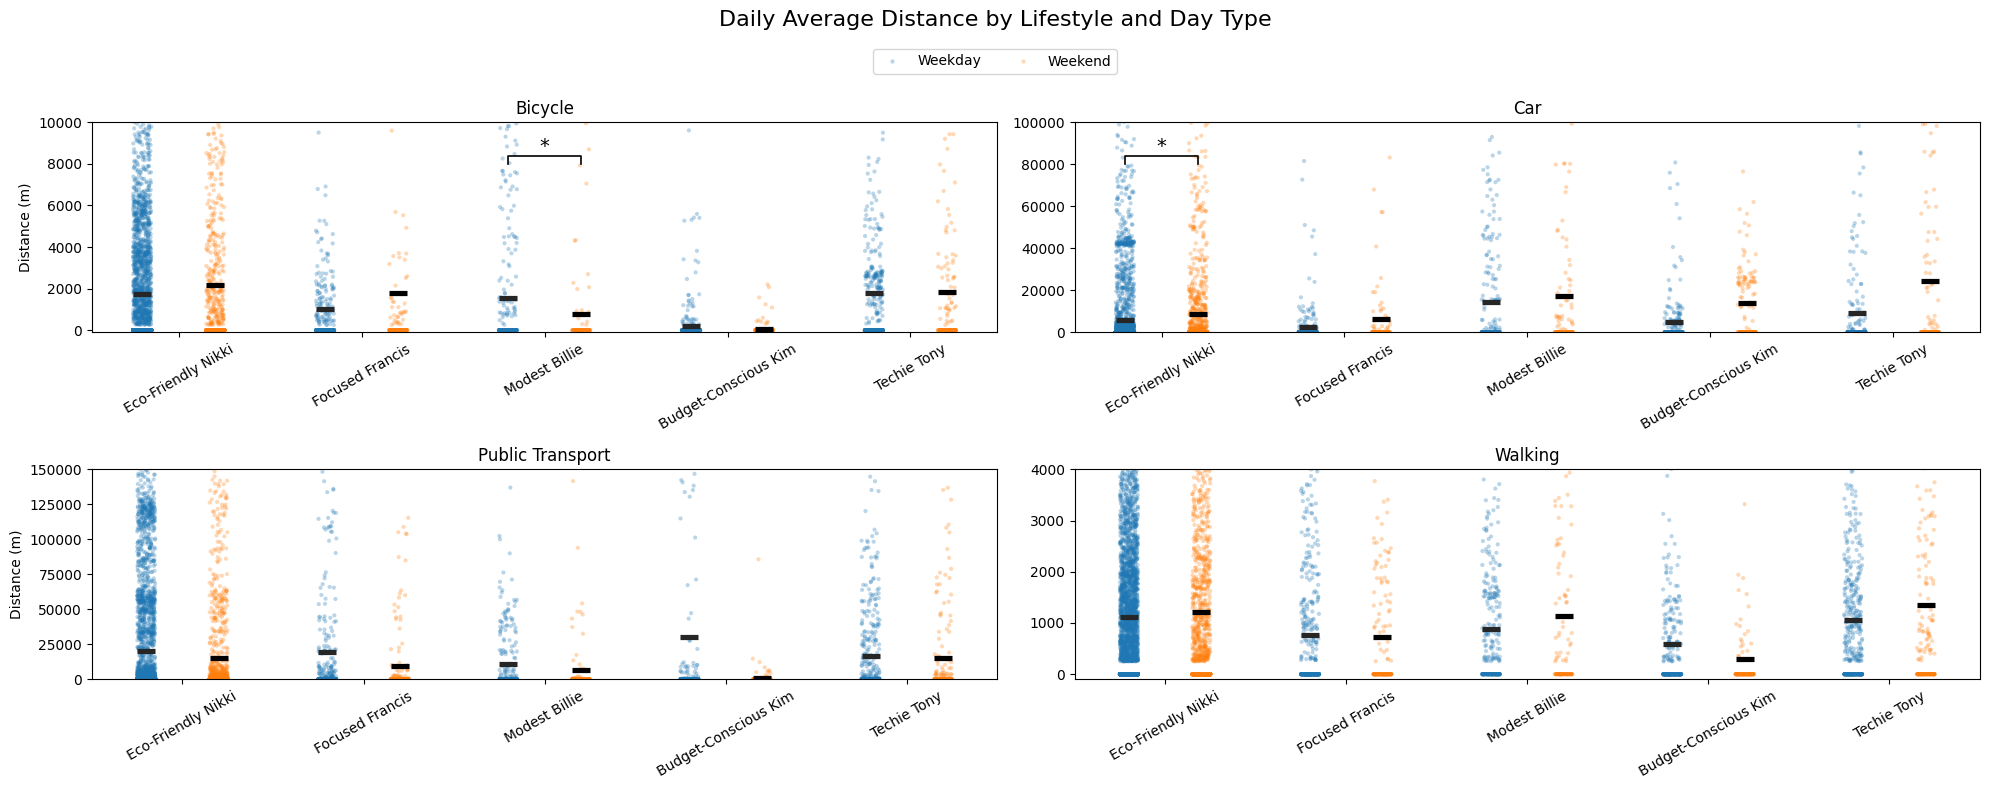

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import permutation_test

# This function tells the test we want to compare the difference in means
def diff_in_means(x, y, axis):
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)

# Base filtering
df = movements.copy()
df = df[~df["mean_of_transport"].isin(["Boat", "DETECTION_ERROR"])]
df = df[~((df["mean_of_transport"] == "Walking") & (df["distance(m)"] > 40000))]
df["day_type"] = np.where(df["is_weekend"], "Weekend", "Weekday")
df = df.dropna(subset=["mean_of_transport", "lifestyle1", "distance(m)", "day_type"])

# Group public transports
df["mean_of_transport"] = df["mean_of_transport"].replace({"Bus": "Public Transport", "Tram": "Public Transport", "Train": "Public Transport", "Boat": "Public Transport"})

# Add zeros for non-travel days per mode
daily_dist = df.groupby(["participant_id", "lifestyle1", "date", "mean_of_transport"])["distance(m)"].sum().reset_index()

# Complete date grid per participant
complete_dates = daily_dist.groupby(["participant_id", "lifestyle1"])["date"].apply(
    lambda x: pd.date_range(x.min(), x.max(), freq='D')
).explode().reset_index(name='date')

# Pivot actual distances
daily_pivot = daily_dist.pivot_table(
    index=["participant_id", "lifestyle1", "date"], 
    columns="mean_of_transport", 
    values="distance(m)", 
    fill_value=0
).reset_index()

# Force both date columns to be exactly the same datetime format before merging
complete_dates["date"] = pd.to_datetime(complete_dates["date"])
daily_pivot["date"] = pd.to_datetime(daily_pivot["date"])

# Merge complete dates with pivoted data
daily_pivot_filled = pd.merge(complete_dates, daily_pivot, on=["participant_id", "lifestyle1", "date"], how="left")

# Fill the new empty days with 0 for all modes
modes_list = daily_dist["mean_of_transport"].unique()
daily_pivot_filled[modes_list] = daily_pivot_filled[modes_list].fillna(0)

# Melt back to long format
df_filled = daily_pivot_filled.melt(
    id_vars=["participant_id", "lifestyle1", "date"], 
    value_vars=modes_list,
    var_name="mean_of_transport", 
    value_name="distance(m)"
)

# Add day_type back
df_filled["day_type"] = np.where(df_filled["date"].dt.dayofweek.isin([5,6]), "Weekend", "Weekday")

modes = sorted(df_filled["mean_of_transport"].unique())
lifestyles_order = df_filled["lifestyle1"].unique() # Standardize order for plotting

# Permutation test:
print("Permutation Tests:")
sig_results = {} # Store significant results

for mode in modes:
    for lifestyle in lifestyles_order:
        subset = df_filled[(df_filled["mean_of_transport"] == mode) & (df_filled["lifestyle1"] == lifestyle)]
        
        # Aggregate to participant level
        user_agg = subset.groupby(['participant_id', 'day_type'])['distance(m)'].mean().unstack()
        user_agg = user_agg.dropna(subset=["Weekday", "Weekend"])

        if len(user_agg) > 3:
            if (user_agg["Weekend"] != user_agg["Weekday"]).any():
                
                # Run the paired permutation test
                res = permutation_test(
                    (user_agg["Weekend"], user_agg["Weekday"]), 
                    statistic=diff_in_means, 
                    permutation_type='samples',
                    n_resamples=9999
                )
                
                p = res.pvalue
                if p < 0.05:
                    diff_mean = user_agg["Weekend"].mean() - user_agg["Weekday"].mean()
                    print(f"{mode} - {lifestyle}: p={p:.4f}, diff (Weekend - Weekday)={diff_mean:.2f}m")
                    
                    # Save the significant lifestyle for this mode
                    if mode not in sig_results:
                        sig_results[mode] = []
                    sig_results[mode].append(lifestyle)

# 4. Plotting
limits = {"Walking": 4000, "Car": 100000, "Bicycle": 10000, "Bus": 20000, "Tram": 15000, "Train": 150000, "Public Transport": 150000}
ncols = 2
nrows = int(np.ceil(len(modes) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(10*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

for i, mode in enumerate(modes):
    ax = axes[i]
    sub = df_filled[df_filled["mean_of_transport"] == mode]

    # Strip plot for individual data points
    sns.stripplot(
        data=sub, x="lifestyle1", y="distance(m)", hue="day_type", order=lifestyles_order,
        dodge=True, alpha=0.3, jitter=True, zorder=1, ax=ax, size=3
    )

    # Draw the mean lines
    sns.pointplot(
        data=sub, x="lifestyle1", y="distance(m)", hue="day_type", order=lifestyles_order,
        dodge=0.4, linestyle="none", markers="_", linewidth=5, palette="dark:black", 
        errorbar=None, zorder=10, ax=ax
    )

    # Draw significance brackets
    if mode in sig_results:
        for ls_idx, ls in enumerate(lifestyles_order):
            if ls in sig_results[mode]:
                x1, x2 = ls_idx - 0.2, ls_idx + 0.2
                
                y_max = sub[sub["lifestyle1"] == ls]["distance(m)"].max()
                y_cap = limits.get(mode, y_max) * 0.8
                y_pos = min(y_max, y_cap) 
                
                ax.plot([x1, x1, x2, x2], [y_pos, y_pos*1.05, y_pos*1.05, y_pos], lw=1.2, color='black')
                ax.text((x1+x2)/2, y_pos*1.05, "*", ha='center', va='bottom', color='black', fontsize=14)

    ax.set_title(mode)
    ax.set_xlabel("")
    ax.set_ylabel("Distance (m)" if i % ncols == 0 else "")
    ax.set_ylim(-100, limits.get(mode, None))
    ax.tick_params(axis="x", rotation=30)

    # Clean up duplicate legends
    handles, labels = ax.get_legend_handles_labels()
    if i == 0:
        fig.legend(handles[:2], labels[:2], title="", loc="upper center", ncol=2, bbox_to_anchor=(0.5, 0.94))
    ax.get_legend().remove()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Daily Average Distance by Lifestyle and Day Type", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [27]:
movements.head()

,participant_id,start_time,end_time,start_geohash,end_geohash,distance(m),mean_of_transport,original_mean_of_transport,gCO2,is_power_saving,dow,is_weekend,date,lifestyle1,lifestyle2
0,4L5S1E,2024-09-03 16:23:18+00:00,2024-09-03 16:25:21+00:00,u0m709,u0m70d,570,Bicycle,Bicycle,3,False,1,False,2024-09-03,Eco-Friendly Nikki,Modest Billie
1,4L5S1E,2024-09-03 17:07:08+00:00,2024-09-03 17:17:04+00:00,u0m709,u0m70f,326,Walking,Walking,0,False,1,False,2024-09-03,Eco-Friendly Nikki,Modest Billie
2,4L5S1E,2024-09-03 17:17:05+00:00,2024-09-03 17:24:40+00:00,u0m70f,u0m716,1857,Bus,Bus,245,False,1,False,2024-09-03,Eco-Friendly Nikki,Modest Billie
3,119817XU1,2024-08-28 07:38:11+00:00,2024-08-28 07:42:14+00:00,u0qnpk,u0qnpk,254,Walking,Walking,0,False,2,False,2024-08-28,Eco-Friendly Nikki,Modest Billie
4,119817XU1,2024-08-28 07:42:15+00:00,2024-08-28 07:44:19+00:00,u0qnpk,u0qnps,598,Bicycle,Bicycle,6,False,2,False,2024-08-28,Eco-Friendly Nikki,Modest Billie


In [28]:
# Compute ratio of modes of transport per person by: time, distance, and number of trips (normalized by total trips per lifestyle)

# Ratio by duration of trips:
# Remove DETECTION_ERROR
movements = movements[movements["mean_of_transport"] != "DETECTION_ERROR"]

# COmpute duration of trips in seconds
movements["duration_sec"] = (movements["end_time"] - movements["start_time"]).dt.total_seconds()
# Group by participant_id, lifestyle1, mean_of_transport and sum duration_sec
duration_by_mode = movements.groupby(["participant_id", "lifestyle1", "mean_of_transport"])["duration_sec"].sum().reset_index()

# Set to 0 duration for modes that are not present for a given participant and lifestyle
all_combinations = pd.MultiIndex.from_product([movements["participant_id"].unique(), movements["lifestyle1"].unique(), movements["mean_of_transport"].unique()], names=["participant_id", "lifestyle1", "mean_of_transport"])
duration_by_mode = duration_by_mode.set_index(["participant_id", "lifestyle1", "mean_of_transport"]).reindex(all_combinations, fill_value=0).reset_index()

# Group by participant_id, lifestyle1 and sum duration_sec to get total duration per lifestyle
total_duration = movements.groupby(["participant_id", "lifestyle1"])["duration_sec"].sum().reset_index().rename(columns={"duration_sec": "total_duration_sec"})
# Merge total duration back to duration_by_mode
duration_by_mode = duration_by_mode.merge(total_duration, on=["participant_id", "lifestyle1"])
# Compute ratio of duration per mode
duration_by_mode["duration_ratio"] = duration_by_mode["duration_sec"] / duration_by_mode["total_duration_sec"]
duration_by_mode.head()

,participant_id,lifestyle1,mean_of_transport,duration_sec,total_duration_sec,duration_ratio
0,4L5S1E,Eco-Friendly Nikki,Bicycle,1249066.0,6058569.0,0.206165
1,4L5S1E,Eco-Friendly Nikki,Walking,1675706.0,6058569.0,0.276584
2,4L5S1E,Eco-Friendly Nikki,Bus,236477.0,6058569.0,0.039032
3,4L5S1E,Eco-Friendly Nikki,Train,2302795.0,6058569.0,0.380089
4,4L5S1E,Eco-Friendly Nikki,Car,402813.0,6058569.0,0.066486


In [29]:
# Compute average, median, and standard deviation of duration_ratio by lifestyle1 and mean_of_transport
duration_stats = duration_by_mode.groupby(["lifestyle1", "mean_of_transport"])["duration_ratio"].agg(["mean", "median", "std"]).reset_index()
duration_stats.head()

,lifestyle1,mean_of_transport,mean,median,std
0,Budget-Conscious Kim,Bicycle,0.059997,0.059997,NaN
1,Budget-Conscious Kim,Boat,0.000000,0.000000,NaN
2,Budget-Conscious Kim,Bus,0.052028,0.052028,NaN
3,Budget-Conscious Kim,Car,0.427019,0.427019,NaN
4,Budget-Conscious Kim,Train,0.319216,0.319216,NaN


In [30]:
def radar_chart(stats_df, title, value_col="mean", max_value=None, min_value=None, order=['Train', 'Walking', 'Car', 'Bicycle', 'Bus', 'Tram', 'Boat', 'Plane']):
    """
    Creates a radar chart comparing lifestyles across modes of transport.
    stats_df should have columns: lifestyle1, mean_of_transport, and the value_col (e.g., mean).
    """
    # Set to 0 the modes that are not present for a lifestyle (e.g., no plane)
    all_modes = stats_df["mean_of_transport"].unique()
    all_lifestyles = stats_df["lifestyle1"].unique()

    # Create a complete DataFrame with all combinations
    complete_df = pd.MultiIndex.from_product([all_lifestyles, all_modes], names=["lifestyle1", "mean_of_transport"]).to_frame(index=False)

    # Merge with filtered durations to get existing values
    pivot = complete_df.merge(stats_df, on=["lifestyle1", "mean_of_transport"], how="left")

    # Fill NaN values with 0
    pivot[value_col] = pivot[value_col].fillna(0)

    # Pivot so each lifestyle is one row
    pivot = pivot.pivot(index="lifestyle1", 
                    columns="mean_of_transport", 
                    values=value_col)

    categories = list(pivot.columns)
    N = len(categories)

    # Sort categories by average across lifestyles
    #category_order = pivot.mean().sort_values(ascending=False).index.tolist()

    category_order = order if order else categories

    # Sort categories by predefined order
    pivot = pivot[category_order]
    categories = category_order

    # Angles for radar
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the circle

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

    for lifestyle in pivot.index:
        values = pivot.loc[lifestyle].tolist()
        values += values[:1]  # close line
        ax.plot(angles, values, label=lifestyle)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)

    ax.set_title(title)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

    if max_value is not None and min_value is not None:
        ax.set_ylim(min_value, max_value)
    elif max_value is not None:
        ax.set_ylim(0, max_value)
    elif min_value is not None:
        ax.set_ylim(min_value, 0)

    plt.tight_layout()
    plt.show()

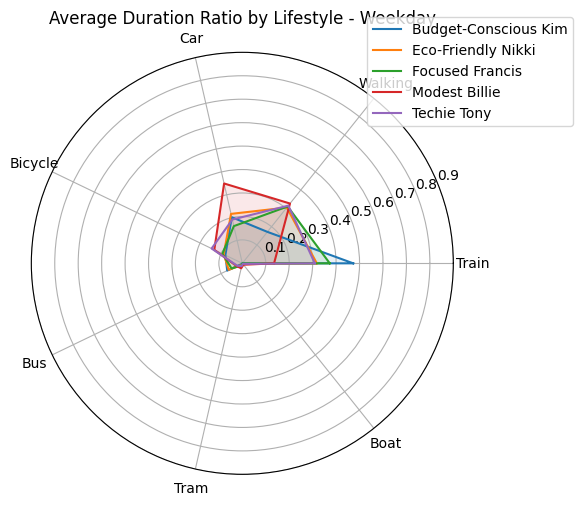

/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_23699/3734724784.py:29: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=duration_stats_temp, x="mean_of_transport", y="median", hue="lifestyle1", marker="o", err_style="bars", ci="sd")


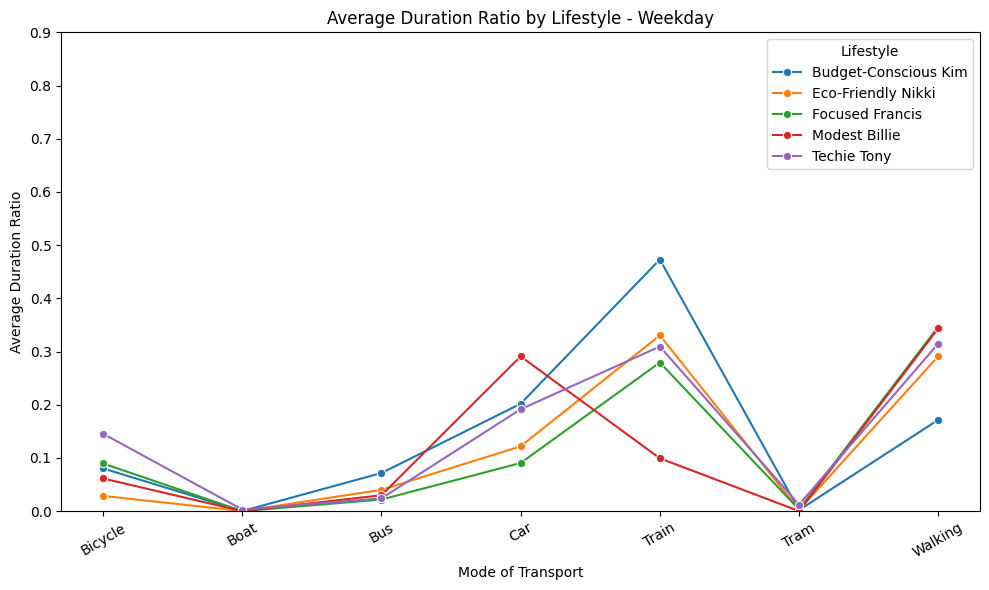

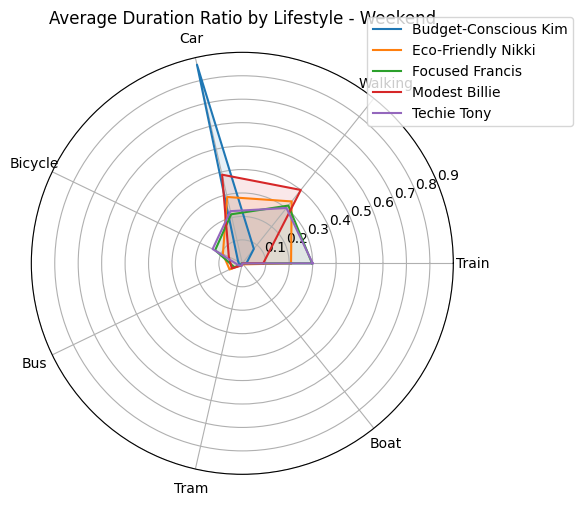

/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_23699/3734724784.py:29: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=duration_stats_temp, x="mean_of_transport", y="median", hue="lifestyle1", marker="o", err_style="bars", ci="sd")


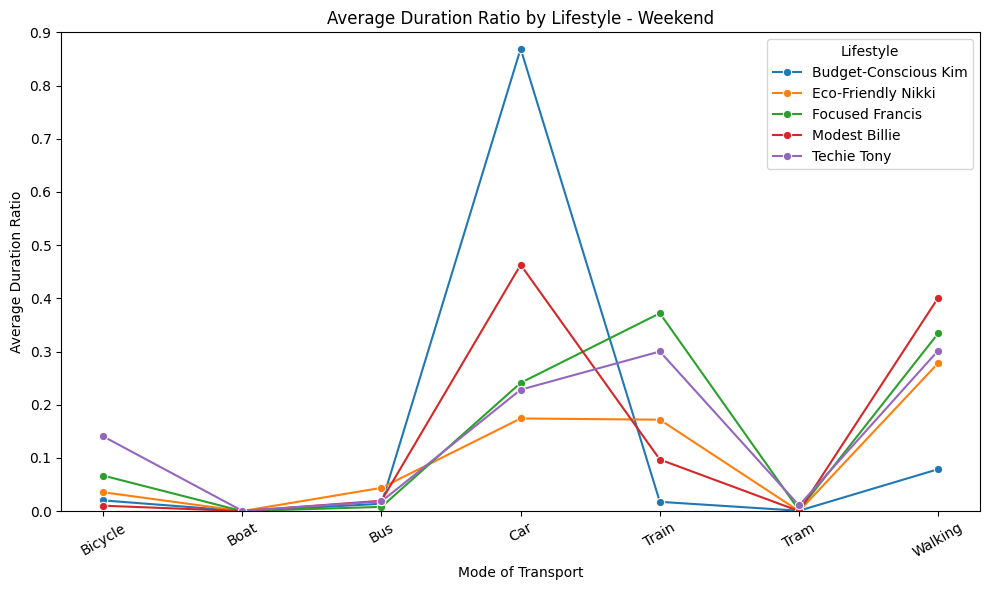

In [31]:
# Radar charts -weekdays vs weekends

# Create list of [lifestyle, mean_of_transport, mean_duration_ratio_weekday, mean_duration_ratio_weekend]
for is_weekend, group in movements.groupby("is_weekend"):
    title = "Weekend" if is_weekend else "Weekday"
    # Group by participant_id, lifestyle1, mean_of_transport and sum duration_sec
    mv_temp = movements[movements["is_weekend"] == is_weekend]
    duration_by_mode_temp = mv_temp.groupby(["participant_id", "lifestyle1", "mean_of_transport"])["duration_sec"].sum().reset_index()

    # Set to 0 duration for modes that are not present for a given participant and lifestyle
    all_combs = pd.MultiIndex.from_product([mv_temp["participant_id"].unique(), mv_temp["lifestyle1"].unique(), mv_temp["mean_of_transport"].unique()], names=["participant_id", "lifestyle1", "mean_of_transport"])
    duration_by_mode_temp = duration_by_mode_temp.set_index(["participant_id", "lifestyle1", "mean_of_transport"]).reindex(all_combs, fill_value=0).reset_index()

    # Group by participant_id, lifestyle1 and sum duration_sec to get total duration per lifestyle
    total_duration_temp = mv_temp.groupby(["participant_id", "lifestyle1"])["duration_sec"].sum().reset_index().rename(columns={"duration_sec": "total_duration_sec"})
    # Merge total duration back to duration_by_mode
    duration_by_mode_temp = duration_by_mode_temp.merge(total_duration_temp, on=["participant_id", "lifestyle1"])

    duration_by_mode_temp["duration_ratio"] = duration_by_mode_temp["duration_sec"] / duration_by_mode_temp["total_duration_sec"]

    # Compute average, median, and standard deviation of duration_ratio by lifestyle1 and mean_of_transport
    duration_stats_temp = duration_by_mode_temp.groupby(["lifestyle1", "mean_of_transport"])["duration_ratio"].agg(["mean", "median", "std"]).reset_index()


    radar_chart(duration_stats_temp, title=f"Average Duration Ratio by Lifestyle - {title}", value_col="mean", max_value=0.9, order = ['Train', 'Walking', 'Car', 'Bicycle', 'Bus', 'Tram', 'Boat'])  # Exclude Plane

    # Plot as line plot with error bars (std)
    plt.figure(figsize=(10,6))
    sns.lineplot(data=duration_stats_temp, x="mean_of_transport", y="median", hue="lifestyle1", marker="o", err_style="bars", ci="sd")
    plt.title(f"Average Duration Ratio by Lifestyle - {title}")
    plt.xlabel("Mode of Transport")
    plt.ylabel("Average Duration Ratio")
    plt.xticks(rotation=30)
    plt.legend(title="Lifestyle")
    plt.ylim(0, 0.9)
    plt.tight_layout()
    plt.show()

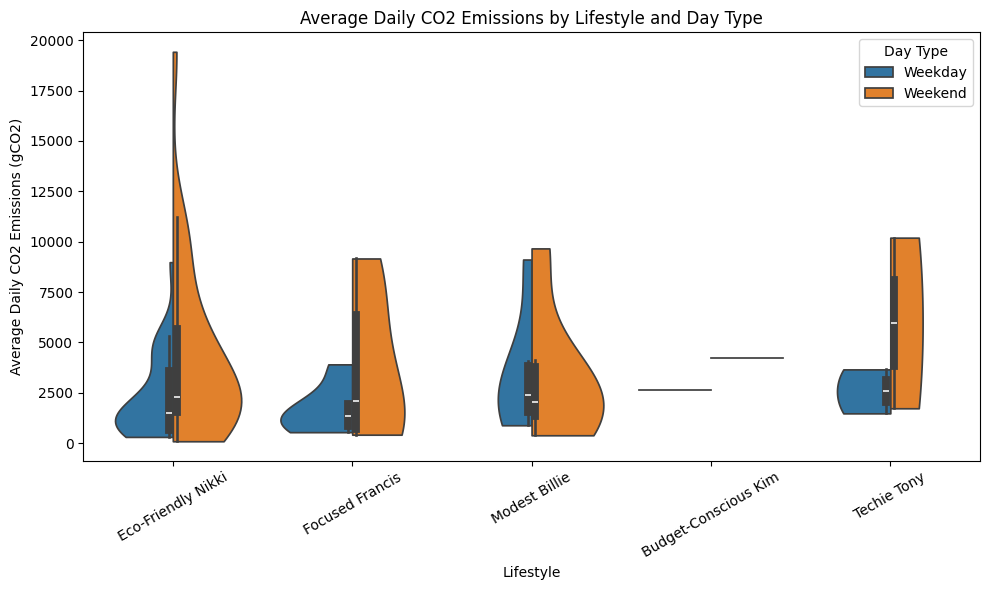

In [32]:
# Compute co2 emissions per day per person - Weekend and weekday
co2_df = movements.groupby(["participant_id", "lifestyle1", "is_weekend", "date"])["gCO2"].sum().reset_index()

# Average co2 emissions per day by lifestyle and weekend/weekday
co2_stats = co2_df.groupby(["participant_id","lifestyle1", "is_weekend"])["gCO2"].agg(["mean", "median", "std"]).reset_index()
co2_stats.head()

# Plot co2 emissions per day by lifestyle and weekend/weekday as violin plot
co2_stats["day_type"] = np.where(co2_stats["is_weekend"], "Weekend", "Weekday")
plt.figure(figsize=(10,6))
sns.violinplot(data=co2_stats, x="lifestyle1", y="mean", hue="day_type", split=True, cut=0)
plt.title("Average Daily CO2 Emissions by Lifestyle and Day Type")
plt.xlabel("Lifestyle")
plt.ylabel("Average Daily CO2 Emissions (gCO2)")
plt.xticks(rotation=30)
plt.legend(title="Day Type")
plt.tight_layout()
plt.show()

In [33]:
pivot = movements.groupby(["lifestyle1", "is_weekend"])["gCO2"].mean().unstack()
print(pivot)

is_weekend                 False        True 
lifestyle1                                   
Budget-Conscious Kim  570.880835  1384.390947
Eco-Friendly Nikki    313.072271   579.700928
Focused Francis       241.646230   500.957490
Modest Billie         775.465442  1215.574924
Techie Tony           565.438674  1306.258486


In [34]:
movements.head(10)

,participant_id,start_time,end_time,start_geohash,end_geohash,distance(m),mean_of_transport,original_mean_of_transport,gCO2,is_power_saving,dow,is_weekend,date,lifestyle1,lifestyle2,duration_sec
0,4L5S1E,2024-09-03 16:23:18+00:00,2024-09-03 16:25:21+00:00,u0m709,u0m70d,570,Bicycle,Bicycle,3,False,1,False,2024-09-03,Eco-Friendly Nikki,Modest Billie,123.0
1,4L5S1E,2024-09-03 17:07:08+00:00,2024-09-03 17:17:04+00:00,u0m709,u0m70f,326,Walking,Walking,0,False,1,False,2024-09-03,Eco-Friendly Nikki,Modest Billie,596.0
2,4L5S1E,2024-09-03 17:17:05+00:00,2024-09-03 17:24:40+00:00,u0m70f,u0m716,1857,Bus,Bus,245,False,1,False,2024-09-03,Eco-Friendly Nikki,Modest Billie,455.0
3,119817XU1,2024-08-28 07:38:11+00:00,2024-08-28 07:42:14+00:00,u0qnpk,u0qnpk,254,Walking,Walking,0,False,2,False,2024-08-28,Eco-Friendly Nikki,Modest Billie,243.0
4,119817XU1,2024-08-28 07:42:15+00:00,2024-08-28 07:44:19+00:00,u0qnpk,u0qnps,598,Bicycle,Bicycle,6,False,2,False,2024-08-28,Eco-Friendly Nikki,Modest Billie,124.0
5,119817XU1,2024-08-29 08:24:27+00:00,2024-08-29 08:29:45+00:00,u0qnpk,u0qnps,1324,Bicycle,Bicycle,14,False,3,False,2024-08-29,Eco-Friendly Nikki,Modest Billie,318.0
6,119817XU1,2024-08-29 13:13:54+00:00,2024-08-29 13:31:21+00:00,u0qnpt,u0qnps,2774,Bicycle,Bicycle,29,False,3,False,2024-08-29,Eco-Friendly Nikki,Modest Billie,1047.0
7,119817XU1,2024-08-30 05:57:25+00:00,2024-08-30 06:07:23+00:00,u0qnps,u0qnpm,664,Walking,Walking,0,False,4,False,2024-08-30,Eco-Friendly Nikki,Modest Billie,598.0
8,119817XU1,2024-08-30 06:07:24+00:00,2024-08-30 06:22:06+00:00,u0qnpm,u0qnnq,4290,Bicycle,Bicycle,45,False,4,False,2024-08-30,Eco-Friendly Nikki,Modest Billie,882.0
9,119817XU1,2024-08-30 10:41:26+00:00,2024-08-30 10:48:03+00:00,u0qnnq,u0qnnq,414,Walking,Walking,0,False,4,False,2024-08-30,Eco-Friendly Nikki,Modest Billie,397.0


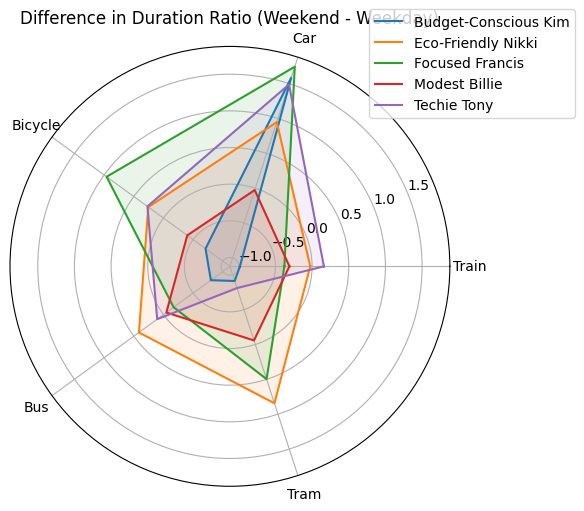

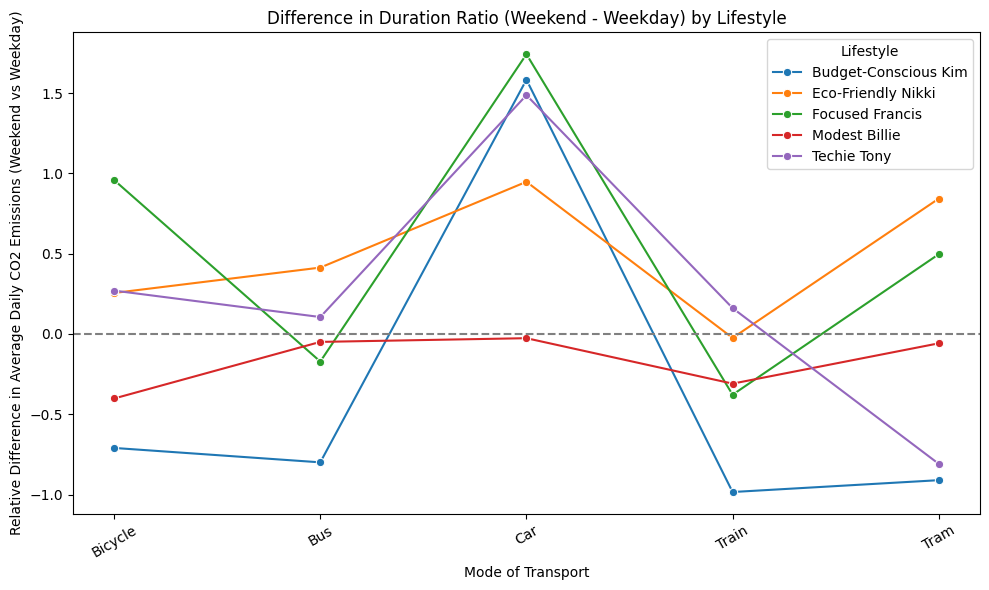

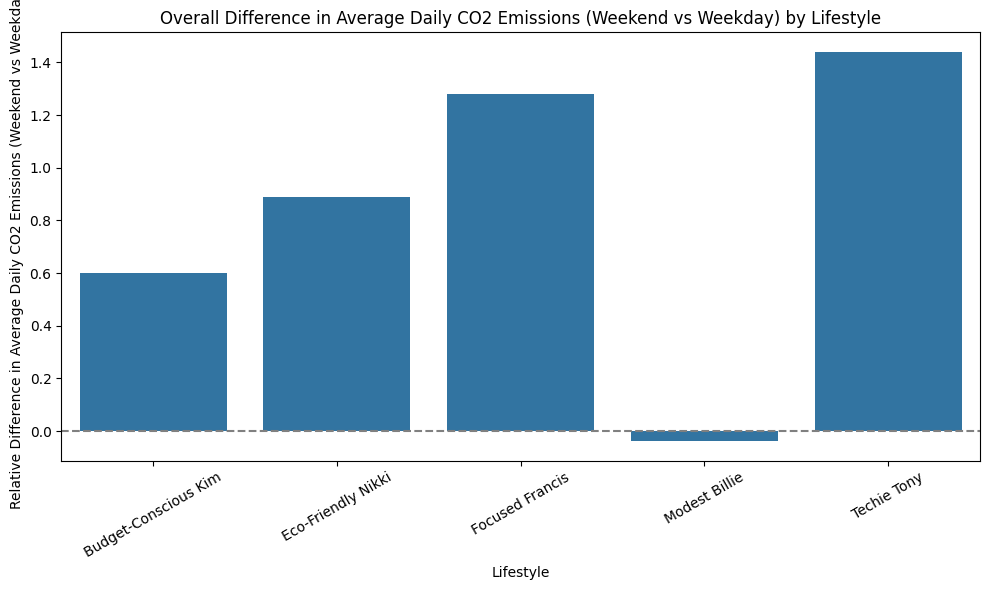

In [35]:
# 1. Compute emissions for both weekdays and weekends, then compute the difference (weekend - weekday) for each person, then average across lifestyles to see which modes of transport have the biggest difference in emissions between weekend and weekday.

# Remove Plane and Boat
mvm = movements[~movements["mean_of_transport"].isin(["Plane", "Boat"])]

# Group by everything including is_weekend to get the base emissions
stats = mvm.groupby(["is_weekend", "participant_id", "lifestyle1", "mean_of_transport"])["gCO2"].sum().reset_index()

# Per each person, calculate the average emissions per day by dividing total emissions by number of unique days with movements
days_per_person = mvm.groupby(["is_weekend", "participant_id", "lifestyle1"])["date"].nunique().reset_index(name="unique_days")
stats = stats.merge(days_per_person, on=["is_weekend", "participant_id", "lifestyle1"])
stats["gCO2_per_day"] = stats["gCO2"] / stats["unique_days"]

# Calculate difference in emissions between weekend and weekday for each person/lifestyle/mode
weekday_stats = stats[stats["is_weekend"] == False].rename(columns={"gCO2_per_day": "weekday_gCO2_per_day"})
weekend_stats = stats[stats["is_weekend"] == True].rename(columns={"gCO2_per_day": "weekend_gCO2_per_day"})
diff = weekend_stats.merge(weekday_stats, on=["participant_id", "lifestyle1", "mean_of_transport"], how="inner")
diff["diff"] = diff["weekend_gCO2_per_day"] - diff["weekday_gCO2_per_day"] # positive means more emissions on weekend, negative means more emissions on weekday
# Average difference by lifestyle and mode of transport
diff_df = diff.groupby(["lifestyle1", "mean_of_transport"])["diff"].mean().reset_index()

# Divide the difference by the average weekday emissions to get a relative difference (e.g., 0.5 means 50% more emissions on weekend, -0.5 means 50% less emissions on weekend)
diff_df = diff_df.merge(weekday_stats.groupby(["lifestyle1", "mean_of_transport"])["weekday_gCO2_per_day"].mean().reset_index(), on=["lifestyle1", "mean_of_transport"])
diff_df["diff"] = diff_df["diff"] / diff_df["weekday_gCO2_per_day"]

# Plot difference in emissions between weekend and weekday by lifestyle and mode of transport as radar chart
# Keep only the following modes:
mots = ['Train', 'Car', 'Bicycle', 'Bus', 'Tram']  # Exclude Boat and Plane and walking (=0 emissions)
diff_df = diff_df[diff_df["mean_of_transport"].isin(mots)]

# If diff > 10 then I put to 0
diff_df["diff"] = diff_df["diff"].apply(lambda x: 0 if abs(x) > 10 else x)

radar_chart(
    diff_df, 
    title="Difference in Duration Ratio (Weekend - Weekday)", 
    value_col="diff",
    order = mots,  # Exclude Boat and Plane
)

# Plot as line plot with error bars (std)
plt.figure(figsize=(10,6))
sns.lineplot(data=diff_df, x="mean_of_transport", y="diff", hue="lifestyle1", marker="o", err_style="bars", errorbar="sd")
# Add horizontal line at y=0
plt.axhline(0, color="gray", linestyle="--")
plt.title("Difference in Duration Ratio (Weekend - Weekday) by Lifestyle")
plt.xlabel("Mode of Transport")
plt.ylabel("Relative Difference in Average Daily CO2 Emissions (Weekend vs Weekday)")
plt.xticks(rotation=30)
plt.legend(title="Lifestyle")
plt.tight_layout()
plt.show()

# Do the same but without separating per mode of transport, to see the overall difference in emissions between weekend and weekday by lifestyle (e.g., maybe some lifestyles have more emissions on weekends because they do more leisure trips, even if the mode of transport is the same)
total_diff = diff.groupby(["lifestyle1"])["diff"].mean().reset_index()
total_diff = total_diff.merge(weekday_stats.groupby(["lifestyle1"])["weekday_gCO2_per_day"].mean().reset_index(), on="lifestyle1")
total_diff["diff"] = total_diff["diff"] / total_diff["weekday_gCO2_per_day"]
plt.figure(figsize=(10,6))
sns.barplot(data=total_diff, x="lifestyle1", y="diff")
plt.axhline(0, color="gray", linestyle="--")
plt.title("Overall Difference in Average Daily CO2 Emissions (Weekend vs Weekday) by Lifestyle")
plt.xlabel("Lifestyle")
plt.ylabel("Relative Difference in Average Daily CO2 Emissions (Weekend vs Weekday)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

,participant_id,lifestyle1,mean_of_transport,date,distance(m),transport_category
0,0L3S1J,Eco-Friendly Nikki,Bicycle,2025-07-09,3235,bike
1,0L3S1J,Eco-Friendly Nikki,Boat,2025-05-26,23118,other
2,0L3S1J,Eco-Friendly Nikki,Bus,2025-05-23,10117,public_transport
3,0L3S1J,Eco-Friendly Nikki,Bus,2025-06-09,3939,public_transport
4,0L3S1J,Eco-Friendly Nikki,Bus,2025-06-23,6543,public_transport


,participant_id,lifestyle1,date,bike,car,other,public_transport
0,0L3S1J,Eco-Friendly Nikki,2025-05-23,0.0,0.0,7131.0,165735.0
1,0L3S1J,Eco-Friendly Nikki,2025-05-26,0.0,0.0,31889.0,47538.0
2,0L3S1J,Eco-Friendly Nikki,2025-05-27,0.0,0.0,3276.0,0.0
3,0L3S1J,Eco-Friendly Nikki,2025-05-28,0.0,0.0,1145.0,21184.0
4,0L3S1J,Eco-Friendly Nikki,2025-06-03,0.0,0.0,1020.0,13347.0


,participant_id,lifestyle1,main_commuting_mode,days_commuted,avg_car_distance,avg_public_transport_distance,avg_bike_distance
0,0L3S1J,Eco-Friendly Nikki,other,8,684.375,2047.500000,0.000000
1,0L3S1J,Eco-Friendly Nikki,public_transport,8,0.000,71998.000000,404.375000
2,0Q1Q9Q,Focused Francis,car,1,25563.000,436.000000,0.000000
3,0Q1Q9Q,Focused Francis,public_transport,10,0.000,60426.500000,421.000000
4,10F11M1A,Eco-Friendly Nikki,bike,52,182.500,148.884615,3929.692308


,lifestyle1,main_commuting_mode,num_regular_commuters
0,Eco-Friendly Nikki,bike,4
1,Eco-Friendly Nikki,car,5
2,Eco-Friendly Nikki,other,5
3,Eco-Friendly Nikki,public_transport,15
4,Focused Francis,other,2


,lifestyle1,num_participants
0,Budget-Conscious Kim,1
1,Eco-Friendly Nikki,31
2,Focused Francis,5
3,Modest Billie,6
4,Techie Tony,2


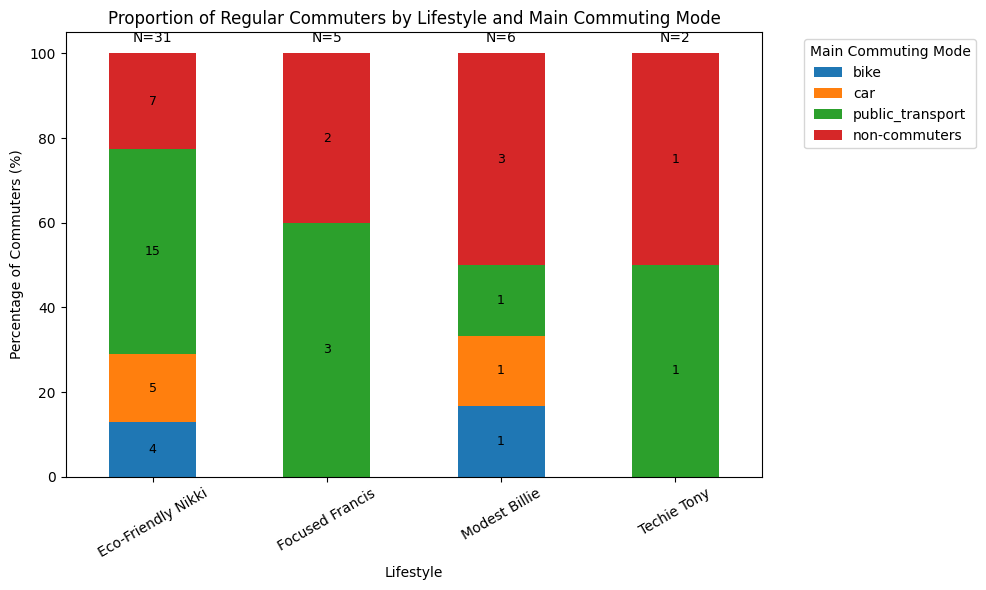

In [36]:
# Check how many people regularly commute during the week, with public transport, car, or mixed modes (e.g., do at least x km during weekdays on average), and see to what lifestyle they belong to
distance_weekdays = movements[movements["is_weekend"] == False].groupby(["participant_id", "lifestyle1", "mean_of_transport", "date"])["distance(m)"].sum().reset_index()

# Convert to distance in the following cateogries: public_transport (train + bus + tram), car, bike
def categorize_transport(mot):
    if mot in ["Train", "Bus", "Tram"]:
        return "public_transport"
    elif mot == "Car":
        return "car"
    elif mot in ["Bicycle", "Electric_Bike"]:
        return "bike"
    else:
        return "other"
    
distance_weekdays["transport_category"] = distance_weekdays["mean_of_transport"].apply(categorize_transport)

display(distance_weekdays.head())

# Get total distance per mode of transport per person per day
distance_weekdays = distance_weekdays.groupby(["participant_id", "lifestyle1", "transport_category", "date"])["distance(m)"].sum().reset_index()

# Put the same days on the same row, by adding the distance of the different modes of transport for the same person, lifestyle, and day (e.g., we add a column for car, public transport and bike, where we indicate the distance covered
distance_weekdays = distance_weekdays.pivot_table(index=["participant_id", "lifestyle1", "date"], columns="transport_category", values="distance(m)", fill_value=0).reset_index()

# Remove transport category column from the columns
distance_weekdays.columns.name = None

display(distance_weekdays.head())

## TODO: Continue here

# For each row, get the main commuting mode. If distance by car and train is more than 5km -> mixed, if only one of them is more than 5km -> that mode, if bicycle more than 2km -> bike, otherwise other
def get_main_commuting_mode(row):
    if row["car"] > 5000 and row["public_transport"] > 5000:
        return "mixed"
    elif row["car"] > 10000:
        return "car"
    elif row["public_transport"] > 10000:
        return "public_transport"
    elif row["bike"] > 2000:
        return "bike"
    else:
        return "other"

# Add the main commuting mode column
distance_weekdays["main_commuting_mode"] = distance_weekdays.apply(get_main_commuting_mode, axis=1)

# For each person, get the number of days they commuted with each mode, and the average distance covered with each mode
commuting_summary = distance_weekdays.groupby(["participant_id", "lifestyle1", "main_commuting_mode"]).agg(
    days_commuted=("date", "nunique"),
    avg_car_distance=("car", "mean"),
    avg_public_transport_distance=("public_transport", "mean"),
    avg_bike_distance=("bike", "mean")
).reset_index()

display(commuting_summary.head())

# Get the number of days in total for which each person has data
total_days = distance_weekdays.groupby(["participant_id", "lifestyle1"])["date"].nunique().reset_index(name="total_days")

# Merge total days back to commuting summary
commuting_summary = commuting_summary.merge(total_days, on=["participant_id", "lifestyle1"])
# Calculate the percentage of days commuted with each mode
commuting_summary["percent_days_commuted"] = commuting_summary["days_commuted"] / commuting_summary["total_days"]

# Get a summary of the number of people who commute regularly (e.g., at least 2 days a week) with each mode
# 1. Get all instances where a person met the >= 40% threshold
qualifying_modes = commuting_summary[commuting_summary["percent_days_commuted"] >= 0.4]

# 2. Group by participant to see ALL the modes they qualified for
person_modes = qualifying_modes.groupby(["participant_id", "lifestyle1"])["main_commuting_mode"].unique().reset_index()

# 3. Assign a single overall mode: if they have >1 qualifying mode, make them "mixed"
# Remove "other" mode, as it doesn't indicate a real commuting mode
person_modes["main_commuting_mode"] = person_modes["main_commuting_mode"].apply(lambda modes: [m for m in modes if m != "other"])

person_modes["overall_mode"] = person_modes["main_commuting_mode"].apply(
    lambda modes: "mixed" if len(modes) > 1 else modes[0] if len(modes) == 1 else "other"
)

# 4. Count unique regular commuters using this single overall mode
regular_commuters = person_modes.groupby(["lifestyle1", "overall_mode"])["participant_id"].nunique().reset_index(name="num_regular_commuters")

# 5. Rename back to match your plotting variables
regular_commuters.rename(columns={"overall_mode": "main_commuting_mode"}, inplace=True)

display(regular_commuters.head())

# Remove other category
regular_commuters = regular_commuters[regular_commuters["main_commuting_mode"] != "other"]

# Get the total number of participants per lifestyle, to be able to compute the percentage of regular commuters per lifestyle
participants_per_lifestyle = movements.groupby("lifestyle1")["participant_id"].nunique().reset_index(name="num_participants")

display(participants_per_lifestyle.head(10))

# 1. Pivot the data
stacked_data = regular_commuters.pivot(
    index="lifestyle1", 
    columns="main_commuting_mode", 
    values="num_regular_commuters"
)

# Add a column with "non-commuters", which are the participants that are not regular commuters with any mode (e.g., they don't have any mode with >= 40% of days commuted)
stacked_data["non-commuters"] = participants_per_lifestyle.set_index("lifestyle1").reindex(stacked_data.index)["num_participants"] - stacked_data.sum(axis=1)

# 2. Normalize the data by row to get percentages (0.0 to 1.0)
percentage_data = stacked_data.div(stacked_data.sum(axis=1), axis=0) * 100

# 3. Plot as a stacked bar chart
plt.figure(figsize=(10, 6))
ax = plt.gca()
percentage_data.plot(kind="bar", stacked=True, ax=ax)

# --- NEW: Add raw numbers inside the segments ---
# We loop through each column's plotted bars and match them to the raw counts
for i, col in enumerate(stacked_data.columns):
    raw_labels = [f"{int(val)}" if val > 0 else "" for val in stacked_data[col]]
    ax.bar_label(ax.containers[i], labels=raw_labels, label_type="center", fontsize=9)
# ------------------------------------------------

# 4. Apply your formatting
plt.title("Proportion of Regular Commuters by Lifestyle and Main Commuting Mode")
plt.xlabel("Lifestyle")
plt.ylabel("Percentage of Commuters (%)")

# Your existing sample size labels
participants_per_lifestyle = participants_per_lifestyle.set_index("lifestyle1").reindex(percentage_data.index).fillna(0).reset_index()
for idx, row in participants_per_lifestyle.iterrows():
    plt.text(idx, 102, f"N={int(row['num_participants'])}", ha="center", va="bottom")

plt.xticks(rotation=30)
plt.legend(title="Main Commuting Mode", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [37]:
# PGet list of commuters
commuters_list = person_modes[((person_modes["overall_mode"] != "non-commuters") & (person_modes["overall_mode"] != "other"))][["participant_id", "lifestyle1", "overall_mode"]]

# Get all participant_ids
all_commuters = commuters_list["participant_id"].unique()

all_commuters

array(['0L3S1J', '0Q1Q9Q', '10H7K1A', '10Z9B1H', '119817XU1', '11W4Y1H',
       '12W4H1U', '2E7B3M', '2F11GXA', '2L1M1R', '3B10M2A', '3H8WXK',
       '3K9V1H', '4C5PXH', '4F2ZXD', '4L5S1E', '4T11G3A', '4Z11FXF',
       '5U3B1R', '5W2RXT', '5W2SXE', '6F10L1F', '6S5T1H', '6T2PXJ',
       '7C3E1I', '8B5V1C', '8F5P1K', '9B11R1G', '9B6T1M', '9M2KXX',
       '9P3WXJ'], dtype=object)

In [38]:
# Do same thing but with distance ratio instead of duration ratio
# Ratio by distance of trips:
# Group by participant_id, lifestyle1, mean_of_transport and sum distance(m)
distance_by_mode = movements.groupby(["participant_id", "lifestyle1", "mean_of_transport"])["distance(m)"].sum().reset_index()

# Set to 0 distance for modes that are not present for a given participant and lifestyle
all_combinations = pd.MultiIndex.from_product([movements["participant_id"].unique(), movements["lifestyle1"].unique(), movements["mean_of_transport"].unique()], names=["participant_id", "lifestyle1", "mean_of_transport"])
distance_by_mode = distance_by_mode.set_index(["participant_id", "lifestyle1", "mean_of_transport"]).reindex(all_combinations, fill_value=0).reset_index()

# Group by participant_id, lifestyle1 and sum distance(m) to get total distance per lifestyle
total_distance = movements.groupby(["participant_id", "lifestyle1"])["distance(m)"].sum().reset_index().rename(columns={"distance(m)": "total_distance(m)"})
# Merge total distance back to distance_by_mode
distance_by_mode = distance_by_mode.merge(total_distance, on=["participant_id", "lifestyle1"])
# Compute ratio of distance per mode
distance_by_mode["distance_ratio"] = distance_by_mode["distance(m)"] / distance_by_mode["total_distance(m)"]
display(distance_by_mode.head())
# Compute average, median, and standard deviation of distance_ratio by lifestyle1 and mean_of_transport
distance_stats = distance_by_mode.groupby(["lifestyle1", "mean_of_transport"])["distance_ratio"].agg(["mean", "median", "std"]).reset_index()
distance_stats.head()

,participant_id,lifestyle1,mean_of_transport,distance(m),total_distance(m),distance_ratio
0,4L5S1E,Eco-Friendly Nikki,Bicycle,5631657,43765636,0.128678
1,4L5S1E,Eco-Friendly Nikki,Walking,1555387,43765636,0.035539
2,4L5S1E,Eco-Friendly Nikki,Bus,1572758,43765636,0.035936
3,4L5S1E,Eco-Friendly Nikki,Train,31646487,43765636,0.723090
4,4L5S1E,Eco-Friendly Nikki,Car,2575302,43765636,0.058843


,lifestyle1,mean_of_transport,mean,median,std
0,Budget-Conscious Kim,Bicycle,0.005115,0.005115,NaN
1,Budget-Conscious Kim,Boat,0.000000,0.000000,NaN
2,Budget-Conscious Kim,Bus,0.044590,0.044590,NaN
3,Budget-Conscious Kim,Car,0.250552,0.250552,NaN
4,Budget-Conscious Kim,Train,0.682336,0.682336,NaN


In [39]:
# Compute ratio by total number of trips per lifestyle
# Group by participant_id, lifestyle1, mean_of_transport and count number of trips
trips_by_mode = movements.groupby(["lifestyle1", "mean_of_transport"]).size().reset_index(name="num_trips")
# Group by participant_id, lifestyle1 and count total number of trips per lifestyle
total_trips = movements.groupby(["lifestyle1"]).size().reset_index(name="total_trips")
# Merge total trips back to trips_by_mode
trips_by_mode = trips_by_mode.merge(total_trips, on=["lifestyle1"])
# Compute ratio of trips per mode
trips_by_mode["mean"] = trips_by_mode["num_trips"] / trips_by_mode["total_trips"]
display(trips_by_mode.head())

,lifestyle1,mean_of_transport,num_trips,total_trips,mean
0,Budget-Conscious Kim,Bicycle,71,1057,0.067171
1,Budget-Conscious Kim,Bus,168,1057,0.158940
2,Budget-Conscious Kim,Car,316,1057,0.298959
3,Budget-Conscious Kim,Train,197,1057,0.186377
4,Budget-Conscious Kim,Tram,8,1057,0.007569


In [40]:
duration_by_mode.head()

,participant_id,lifestyle1,mean_of_transport,duration_sec,total_duration_sec,duration_ratio
0,4L5S1E,Eco-Friendly Nikki,Bicycle,1249066.0,6058569.0,0.206165
1,4L5S1E,Eco-Friendly Nikki,Walking,1675706.0,6058569.0,0.276584
2,4L5S1E,Eco-Friendly Nikki,Bus,236477.0,6058569.0,0.039032
3,4L5S1E,Eco-Friendly Nikki,Train,2302795.0,6058569.0,0.380089
4,4L5S1E,Eco-Friendly Nikki,Car,402813.0,6058569.0,0.066486


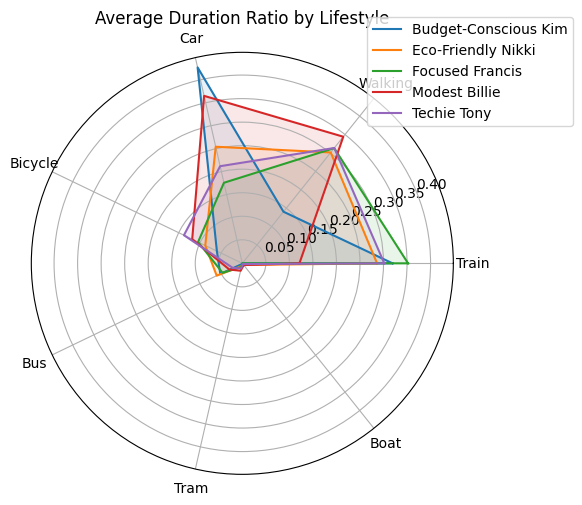

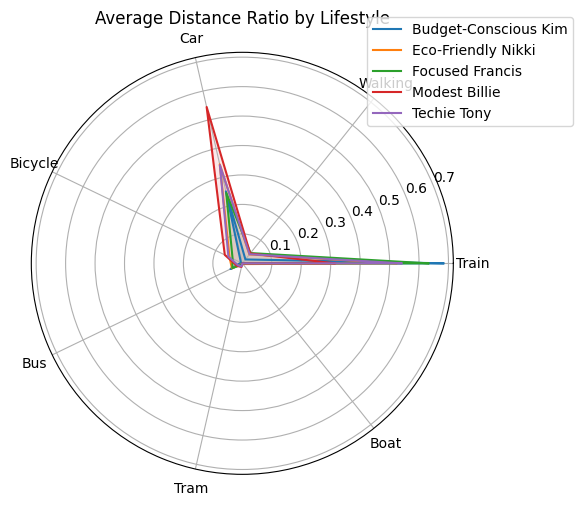

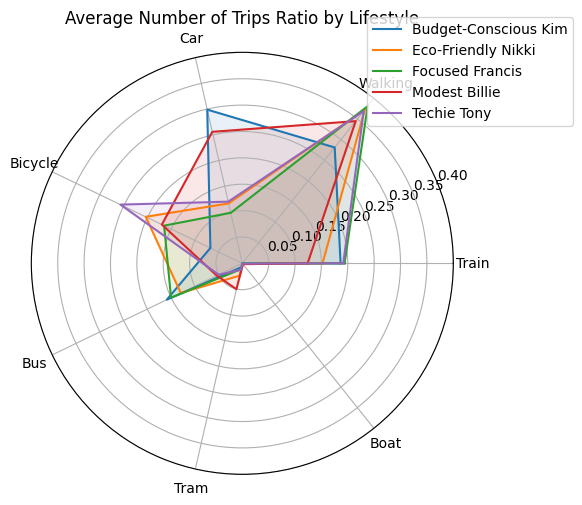

In [41]:
# Radar chart comparing lifestyles across modes of transport by average duration ratio
radar_chart(duration_stats, title="Average Duration Ratio by Lifestyle", value_col="mean", order = ['Train', 'Walking', 'Car', 'Bicycle', 'Bus', 'Tram', 'Boat'])
# Radar chart comparing lifestyles across modes of transport by average distance ratio
radar_chart(distance_stats, title="Average Distance Ratio by Lifestyle", value_col="mean", order = ['Train', 'Walking', 'Car', 'Bicycle', 'Bus', 'Tram', 'Boat'])
# Radar chart comparing lifestyles across modes of transport by average number of trips ratio
radar_chart(trips_by_mode, title="Average Number of Trips Ratio by Lifestyle", value_col="mean", order = ['Train', 'Walking', 'Car', 'Bicycle', 'Bus', 'Tram', 'Boat'])

In [42]:
# Transform movemnets into a list of places visited, where we assume that people stay at a certain location from the end of a movement to the start of the next movement, using end_geohash. Also estimate form when to when a person remained at that location
def movements_to_places(movements):
    places = []
    for participant_id, group in movements.groupby("participant_id"):
        group = group.sort_values("start_time")
        for i in range(len(group) - 1):
            end_geohash = group.iloc[i]["end_geohash"]
            start_time = group.iloc[i]["end_time"]
            end_time = group.iloc[i + 1]["start_time"]
            lifestyle1 = group.iloc[i]["lifestyle1"]

            if pd.isna(end_geohash) or pd.isna(start_time) or pd.isna(end_time):
                continue

            places.append({
                "participant_id": participant_id,
                "lifestyle1": lifestyle1,
                "geohash": end_geohash,
                "start_time": start_time,
                "end_time": end_time
            })

    return pd.DataFrame(places)

places = movements_to_places(movements)

# Compute duration of stay at each place in seconds
places["duration_sec"] = (places["end_time"] - places["start_time"]).dt.total_seconds()

# Remove stays that were longer than 24 hours (possible outliers due to missing movements)
places = places[places["duration_sec"] <= 24 * 3600]

places.head()

,participant_id,lifestyle1,geohash,start_time,end_time,duration_sec
0,0L3S1J,Eco-Friendly Nikki,u0qnnr,2025-05-23 10:02:25+00:00,2025-05-23 10:02:53+00:00,28.0
1,0L3S1J,Eco-Friendly Nikki,u0qjd2,2025-05-23 10:30:21+00:00,2025-05-23 10:56:14+00:00,1553.0
2,0L3S1J,Eco-Friendly Nikki,u0qewu,2025-05-23 12:00:42+00:00,2025-05-23 12:26:36+00:00,1554.0
3,0L3S1J,Eco-Friendly Nikki,u0qdkf,2025-05-23 13:13:57+00:00,2025-05-23 13:13:58+00:00,1.0
4,0L3S1J,Eco-Friendly Nikki,u0qd7b,2025-05-23 15:04:36+00:00,2025-05-23 15:21:01+00:00,985.0


In [43]:
# Compute location by hours for each participant (e.g., if places is from 10:02 to 12:45, we create three new lines for that participant: 10:00-11:00, 11:00-12:00, 12:00-13:00 and that location. without weights).
display(places)
places_by_hour = fractional_hours(places, start_col="start_time", end_col="end_time")
places_by_hour = places_by_hour.drop(columns=["weight", "duration_sec"])
display(places_by_hour)

,participant_id,lifestyle1,geohash,start_time,end_time,duration_sec
0,0L3S1J,Eco-Friendly Nikki,u0qnnr,2025-05-23 10:02:25+00:00,2025-05-23 10:02:53+00:00,28.0
1,0L3S1J,Eco-Friendly Nikki,u0qjd2,2025-05-23 10:30:21+00:00,2025-05-23 10:56:14+00:00,1553.0
2,0L3S1J,Eco-Friendly Nikki,u0qewu,2025-05-23 12:00:42+00:00,2025-05-23 12:26:36+00:00,1554.0
3,0L3S1J,Eco-Friendly Nikki,u0qdkf,2025-05-23 13:13:57+00:00,2025-05-23 13:13:58+00:00,1.0
4,0L3S1J,Eco-Friendly Nikki,u0qd7b,2025-05-23 15:04:36+00:00,2025-05-23 15:21:01+00:00,985.0
...,...,...,...,...,...,...
29799,9S11M3D,Modest Billie,u0qnq8,2025-07-16 19:26:28+00:00,2025-07-17 05:11:25+00:00,35097.0
29800,9S11M3D,Modest Billie,u0qnnq,2025-07-17 05:19:43+00:00,2025-07-17 15:00:42+00:00,34859.0
29801,9S11M3D,Modest Billie,u0qnxu,2025-07-17 15:25:14+00:00,2025-07-17 16:43:19+00:00,4685.0
29802,9S11M3D,Modest Billie,u0qnnq,2025-07-17 17:00:40+00:00,2025-07-17 19:18:33+00:00,8273.0


,participant_id,lifestyle1,geohash,start_time,end_time,hour_of_day
0,0L3S1J,Eco-Friendly Nikki,u0qnnr,2025-05-23 10:02:25+00:00,2025-05-23 10:02:53+00:00,10
1,0L3S1J,Eco-Friendly Nikki,u0qjd2,2025-05-23 10:30:21+00:00,2025-05-23 10:56:14+00:00,10
2,0L3S1J,Eco-Friendly Nikki,u0qewu,2025-05-23 12:00:42+00:00,2025-05-23 12:26:36+00:00,12
3,0L3S1J,Eco-Friendly Nikki,u0qdkf,2025-05-23 13:13:57+00:00,2025-05-23 13:13:58+00:00,13
4,0L3S1J,Eco-Friendly Nikki,u0qd7b,2025-05-23 15:04:36+00:00,2025-05-23 15:21:01+00:00,15
...,...,...,...,...,...,...
124465,9S11M3D,Modest Billie,u0qnq8,2025-07-17 19:23:15+00:00,2025-07-18 05:19:21+00:00,1
124466,9S11M3D,Modest Billie,u0qnq8,2025-07-17 19:23:15+00:00,2025-07-18 05:19:21+00:00,2
124467,9S11M3D,Modest Billie,u0qnq8,2025-07-17 19:23:15+00:00,2025-07-18 05:19:21+00:00,3
124468,9S11M3D,Modest Billie,u0qnq8,2025-07-17 19:23:15+00:00,2025-07-18 05:19:21+00:00,4


In [44]:
# Count occurrence of night time at each location for each participant_id. Then the most visited during the night is home, the most visited durign the day is work and the rest other
night_hours = [22, 23, 0, 1, 2, 3, 4, 5]
day_hours = [9, 10, 11, 12, 13, 14, 15, 16]

night_hours = [22, 23, 0, 1, 2, 3, 4, 5]
day_hours   = [9, 10, 11, 12, 13, 14, 15, 16]

counts_night = (
    places_by_hour[places_by_hour["hour_of_day"].isin(night_hours)]
    .groupby(["participant_id", "geohash"])
    .size()
    .reset_index(name="night_count")
)

counts_day = (
    places_by_hour[places_by_hour["hour_of_day"].isin(day_hours)]
    .groupby(["participant_id", "geohash"])
    .size()
    .reset_index(name="day_count")
)

# Home = argmax night_count per participant
home_locations = (
    counts_night.sort_values(["participant_id", "night_count", "geohash"], ascending=[True, False, True])
    .drop_duplicates("participant_id")
    .rename(columns={"geohash": "home_geohash"})[["participant_id", "home_geohash"]]
)

counts_day_nohome = counts_day.merge(home_locations, on="participant_id", how="left")
counts_day_nohome = counts_day_nohome[(counts_day_nohome["geohash"] != counts_day_nohome["home_geohash"]) | counts_day_nohome["home_geohash"].isna()]

work_locations = (
    counts_day_nohome.sort_values(["participant_id", "day_count", "geohash"], ascending=[True, False, True])
    .drop_duplicates("participant_id")
    .rename(columns={"geohash": "work_geohash"})[["participant_id", "work_geohash"]]
)

display(home_locations.head())
display(work_locations.head())

,participant_id,home_geohash
8,0L3S1J,u0qnnq
12,0Q1Q9Q,u0qj8h
21,10F11M1A,u0m44r
39,10H7K1A,u0qnnq
54,10Z9B1H,u0qnnq


,participant_id,work_geohash
19,0L3S1J,u0qnnm
60,0Q1Q9Q,u0qnnq
107,10F11M1A,u0m44y
207,10H7K1A,u0qq6z
249,10Z9B1H,u0qjex


In [45]:
# Merg the home and work locations in the same dataframe, so that we can map them in pairs on a map
home_work_locations = home_locations.merge(work_locations, on="participant_id", how="outer")

# Find coordinates of home and work geohashes
home_work_locations = home_work_locations.merge(geo_to_coords.rename(columns={"geohash": "home_geohash", "latitude": "home_latitude", "longitude": "home_longitude"}), on="home_geohash", how="left")
home_work_locations = home_work_locations.merge(geo_to_coords.rename(columns={"geohash": "work_geohash", "latitude": "work_latitude", "longitude": "work_longitude"}), on="work_geohash", how="left")

# Add lifestyle1 to home_work_locations
home_work_locations = home_work_locations.merge(lifestyles[['participantid', 'lifestyle1']], left_on='participant_id', right_on='participantid', how='left').drop(columns=['participantid'])

display(home_work_locations.head())

,participant_id,home_geohash,work_geohash,home_latitude,home_longitude,work_latitude,work_longitude,lifestyle1
0,0L3S1J,u0qnnq,u0qnnm,47.49664306640625,8.7176513671875,47.49114990234375,8.7176513671875,Eco-Friendly Nikki
1,0Q1Q9Q,u0qj8h,u0qnnq,47.39776611328125,8.4429931640625,47.49664306640625,8.7176513671875,Focused Francis
2,10F11M1A,u0m44r,u0m44y,46.79901123046875,7.1356201171875,46.79351806640625,7.1575927734375,Eco-Friendly Nikki
3,10H7K1A,u0qnnq,u0qq6z,47.49664306640625,8.7176513671875,47.54608154296875,8.9154052734375,Eco-Friendly Nikki
4,10Z9B1H,u0qnnq,u0qjex,47.49664306640625,8.7176513671875,47.41424560546875,8.5968017578125,Eco-Friendly Nikki


In [46]:
# Build map with home-work location pairs, colored by lifestyle1, on a pydeck map. We can use lines to connect home and work locations, and color them by lifestyle1. We can also add points for home and work locations. Let's use arclayer for lines and scatterplotlayer for points.
import pydeck as pdk
import numpy as np

hw = home_work_locations.dropna(
    subset=["home_latitude", "home_longitude", "work_latitude", "work_longitude", "lifestyle1", "participant_id"]
).copy()

# Ensure plain floats
for c in ["home_latitude", "home_longitude", "work_latitude", "work_longitude"]:
    hw[c] = pd.to_numeric(hw[c], errors="coerce")
hw = hw.dropna(subset=["home_latitude", "home_longitude", "work_latitude", "work_longitude"])

# Ensure plain strings/ints (avoid pandas extension dtypes)
hw["participant_id"] = hw["participant_id"].astype(str)
hw["lifestyle1"] = hw["lifestyle1"].astype(str)

# Deterministic RGB colors (plain Python ints)
codes = hw["lifestyle1"].astype("category").cat.codes.to_numpy().astype(np.int32)
rgb = np.stack([
    (37 * codes + 50) % 256,
    (97 * codes + 80) % 256,
    (53 * codes + 110) % 256,
], axis=1).astype(int)

hw["color"] = [list(map(int, row)) for row in rgb]

# Edit color for target location to be red
hw["target_color"] = hw["color"].apply(lambda c: [255, 0, 0])

# Arc positions as plain python floats
hw["source"] = hw[["home_longitude", "home_latitude"]].apply(lambda r: [float(r[0]), float(r[1])], axis=1)
hw["target"] = hw[["work_longitude", "work_latitude"]].apply(lambda r: [float(r[0]), float(r[1])], axis=1)

# IMPORTANT: only keep columns that layers/tooltip use (drops any shapely/other objects)
arc_data = hw[["participant_id", "lifestyle1", "color", "target_color", "source", "target"]].to_dict("records")
home_data = hw[["participant_id", "lifestyle1", "color", "target_color",  "home_longitude", "home_latitude"]].to_dict("records")
work_data = hw[["participant_id", "lifestyle1", "color", "target_color", "work_longitude", "work_latitude"]].to_dict("records")

deck = pdk.Deck(
    initial_view_state=pdk.ViewState(latitude=46.8, longitude=8.3, zoom=7, pitch=0),
    layers=[
        pdk.Layer(
            "ArcLayer",
            data=arc_data,
            get_source_position="source",
            get_target_position="target",
            get_source_color="color",
            get_target_color="target_color",
            get_width=2,
            pickable=True,
            get_height=0.5
        ),
        pdk.Layer(
            "ScatterplotLayer",
            data=home_data,
            get_position=["home_longitude", "home_latitude"],
            get_fill_color="color",
            get_radius=120,
            pickable=True,
        ),
        pdk.Layer(
            "ScatterplotLayer",
            data=work_data,
            get_position=["work_longitude", "work_latitude"],
            get_fill_color="target_color",
            get_radius=40,
            pickable=True,
        ),
    ],
    tooltip={"text": "id: {participant_id}\nlifestyle: {lifestyle1}"},
)

deck.to_html("maps/home_work_locations_map.html")
! open maps/home_work_locations_map.html



/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_23699/666758857.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hw["source"] = hw[["home_longitude", "home_latitude"]].apply(lambda r: [float(r[0]), float(r[1])], axis=1)
/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_23699/666758857.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hw["target"] = hw[["work_longitude", "work_latitude"]].apply(lambda r: [float(r[0]), float(r[1])], axis=1)


In [47]:
# Get coordinates for all places:
# If needed: attach lat/lon to every place observation
places = places_by_hour.merge(geo_to_coords, on="geohash", how="left").dropna(subset=["latitude","longitude"])
display(places.head())

,participant_id,lifestyle1,geohash,start_time,end_time,hour_of_day,latitude,longitude
0,0L3S1J,Eco-Friendly Nikki,u0qnnr,2025-05-23 10:02:25+00:00,2025-05-23 10:02:53+00:00,10,47.50213623046875,8.7176513671875
1,0L3S1J,Eco-Friendly Nikki,u0qjd2,2025-05-23 10:30:21+00:00,2025-05-23 10:56:14+00:00,10,47.37579345703125,8.5418701171875
2,0L3S1J,Eco-Friendly Nikki,u0qewu,2025-05-23 12:00:42+00:00,2025-05-23 12:26:36+00:00,12,47.04620361328125,9.4427490234375
3,0L3S1J,Eco-Friendly Nikki,u0qdkf,2025-05-23 13:13:57+00:00,2025-05-23 13:13:58+00:00,13,46.81549072265625,9.3548583984375
4,0L3S1J,Eco-Friendly Nikki,u0qd7b,2025-05-23 15:04:36+00:00,2025-05-23 15:21:01+00:00,15,46.80450439453125,9.3109130859375


In [48]:
# Compute duration of stay at each place in seconds
places["duration_sec"] = (places["end_time"] - places["start_time"]).dt.total_seconds()
# Remove stays that were longer than 48 hours (possible outliers due to missing movements)
places_filtered = places[places["duration_sec"] <= 48 * 3600]
display(places_filtered.head())

,participant_id,lifestyle1,geohash,start_time,end_time,hour_of_day,latitude,longitude,duration_sec
0,0L3S1J,Eco-Friendly Nikki,u0qnnr,2025-05-23 10:02:25+00:00,2025-05-23 10:02:53+00:00,10,47.50213623046875,8.7176513671875,28.0
1,0L3S1J,Eco-Friendly Nikki,u0qjd2,2025-05-23 10:30:21+00:00,2025-05-23 10:56:14+00:00,10,47.37579345703125,8.5418701171875,1553.0
2,0L3S1J,Eco-Friendly Nikki,u0qewu,2025-05-23 12:00:42+00:00,2025-05-23 12:26:36+00:00,12,47.04620361328125,9.4427490234375,1554.0
3,0L3S1J,Eco-Friendly Nikki,u0qdkf,2025-05-23 13:13:57+00:00,2025-05-23 13:13:58+00:00,13,46.81549072265625,9.3548583984375,1.0
4,0L3S1J,Eco-Friendly Nikki,u0qd7b,2025-05-23 15:04:36+00:00,2025-05-23 15:21:01+00:00,15,46.80450439453125,9.3109130859375,985.0


In [49]:
import numpy as np
import pandas as pd
from pyproj import Transformer

# Compute the RADIUS OF GYRATION for each participant, which is a measure of the spatial spread of their visited locations. It is defined as the root mean square distance of the visited locations from their center of mass (average location). We will compute it in meters, so we need to transform the lat/lon coordinates to a projected coordinate system (e.g., Swiss LV95) before computing distances.
# Normalize the radius of gyration by the time spent at each location

WGS84_TO_LV95 = Transformer.from_crs("EPSG:4326", "EPSG:2056", always_xy=True)

def radius_of_gyration(group: pd.DataFrame) -> float:
    lon = group["longitude"].to_numpy(float)
    lat = group["latitude"].to_numpy(float)
    x, y = WGS84_TO_LV95.transform(lon, lat)

    x = np.asarray(x, float); y = np.asarray(y, float)
    if len(x) < 2:
        return np.nan

    x_cm = x.mean()
    y_cm = y.mean()
    rg = np.sqrt(np.mean((x - x_cm)**2 + (y - y_cm)**2))
    return float(rg)

def daily_rg(
    places: pd.DataFrame,
    id_col: str = "participant_id",
    time_col: str = "timestamp",   # change if needed
    lat_col: str = "latitude",
    lon_col: str = "longitude",
    tz: str = "Europe/Zurich",
    min_points_per_day: int = 2,
) -> pd.DataFrame:
    df = places.copy()

    # Parse timestamps and convert to local date
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce", utc=True)
    df = df.dropna(subset=[id_col, time_col, lat_col, lon_col])

    df["local_time"] = df[time_col].dt.tz_convert(tz)
    df["date"] = df["local_time"].dt.floor("D")
    df["is_weekend"] = df["local_time"].dt.weekday.isin([5, 6])

    # Ensure numeric coords
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")
    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    df = df.dropna(subset=[lat_col, lon_col])

    # Project to LV95 meters (vectorized for all rows)
    x, y = WGS84_TO_LV95.transform(df[lon_col].to_numpy(float), df[lat_col].to_numpy(float))
    df["x"] = np.asarray(x, float)
    df["y"] = np.asarray(y, float)

    def _rg(g: pd.DataFrame) -> float:
        xy = g[["x", "y"]].to_numpy(float)
        if len(xy) < min_points_per_day:
            return np.nan
        x_cm = xy[:, 0].mean()
        y_cm = xy[:, 1].mean()
        return float(np.sqrt(np.mean((xy[:, 0] - x_cm) ** 2 + (xy[:, 1] - y_cm) ** 2)))

    rg_daily = (
        df.groupby([id_col, "date"], sort=False)
          .apply(_rg)
          .reset_index(name="rg_m")
    )

    # add weekend flag + count of points used
    pts_n = df.groupby([id_col, "date"], sort=False).size().reset_index(name="n_points")
    wknd = df.groupby([id_col, "date"], sort=False)["is_weekend"].first().reset_index()

    rg_daily = rg_daily.merge(pts_n, on=[id_col, "date"], how="left").merge(wknd, on=[id_col, "date"], how="left")
    return rg_daily.sort_values([id_col, "date"]).reset_index(drop=True)

# Usage:
# rg_daily = daily_rg(places, time_col="timestamp")  # adapt time_col if needed
# display(rg_daily.head())



rg_daily = daily_rg(places, time_col="start_time")  # adapt time_col if needed

rg_per_person = (
    places.groupby("participant_id")
    .apply(radius_of_gyration)
    .reset_index(name="rg_m")
)

display(rg_daily.head())
display(rg_per_person.head())

/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_23699/1066410301.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_rg)
/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_23699/1066410301.py:84: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(radius_of_gyration)


,participant_id,date,rg_m,n_points,is_weekend
0,0L3S1J,2025-05-23 00:00:00+02:00,25594.478627,26,False
1,0L3S1J,2025-05-24 00:00:00+02:00,NaN,1,True
2,0L3S1J,2025-05-26 00:00:00+02:00,8226.877920,31,False
3,0L3S1J,2025-05-27 00:00:00+02:00,323.543436,29,False
4,0L3S1J,2025-05-28 00:00:00+02:00,359.982017,7,False


,participant_id,rg_m
0,0L3S1J,28039.783749
1,0Q1Q9Q,32441.203337
2,10F11M1A,14473.753598
3,10H7K1A,28483.073898
4,10Z9B1H,22106.444175


In [50]:
# Show the people with the biggest radius of gyration (most spatially spread out)
display(rg_per_person.sort_values("rg_m", ascending=False).head(10))
display(rg_daily.sort_values("rg_m", ascending=False).head(10))

,participant_id,rg_m
20,4C5PXH,78531.839214
10,1G2T1K,70194.893134
38,8F5P1K,67038.014898
23,4T11G3A,61647.425310
27,5U3B1R,59204.265696
21,4F2ZXD,59089.099954
13,2E7B3M,58570.006984
22,4L5S1E,50361.551108
25,4Z11FXF,47874.481731
5,119817XU1,47579.706039


,participant_id,date,rg_m,n_points,is_weekend
1302,4C5PXH,2025-03-01 00:00:00+01:00,124769.388980,9,True
2437,5U3B1R,2025-01-26 00:00:00+01:00,106857.873734,26,True
1476,4L5S1E,2024-12-15 00:00:00+01:00,100392.403654,36,True
2077,4Z11FXF,2025-09-21 00:00:00+02:00,93708.700088,28,True
1280,3K9V1H,2025-08-14 00:00:00+02:00,93265.110499,12,False
2074,4Z11FXF,2025-09-18 00:00:00+02:00,90979.518068,32,False
1547,4L5S1E,2025-03-11 00:00:00+01:00,89616.830507,26,False
3951,8G2B2C,2025-02-13 00:00:00+01:00,88307.399324,3,False
2490,5U3B1R,2025-04-24 00:00:00+02:00,86613.409791,28,False
344,119817XU1,2024-09-11 00:00:00+02:00,84842.355708,32,False


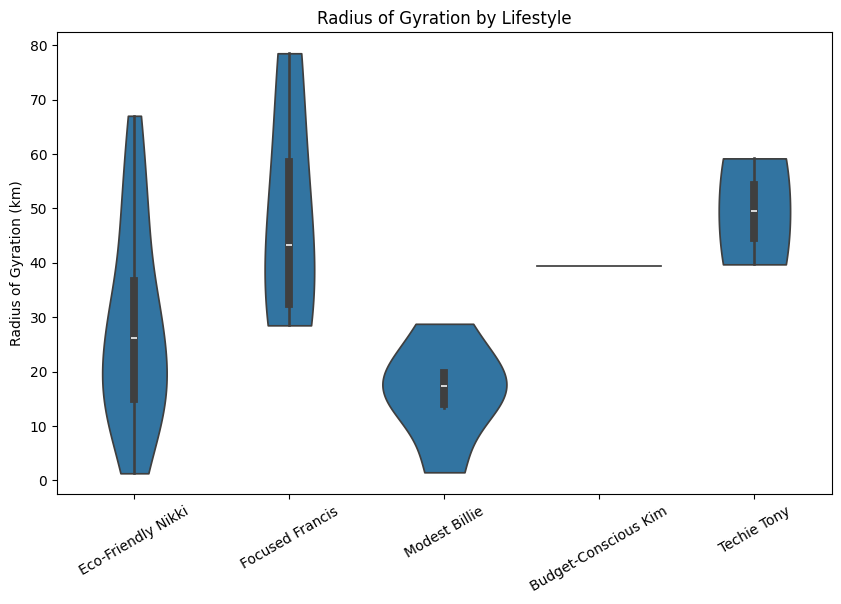

In [51]:
# Plot radius of gyration in km by lifestyle1 (violin plot)
rg_per_person_km = rg_per_person.merge(lifestyles[['participantid', 'lifestyle1']], left_on='participant_id', right_on='participantid', how='left').drop(columns=['participantid'])
rg_per_person_km["rg_km"] = rg_per_person_km["rg_m"] / 1000 # convert to km for better readability

plt.figure(figsize=(10,6))
sns.violinplot(data=rg_per_person_km, x="lifestyle1", y="rg_km", cut=0)
plt.title("Radius of Gyration by Lifestyle")
plt.xlabel("")
plt.ylabel("Radius of Gyration (km)")
plt.xticks(rotation=30)
plt.show()

In [52]:
rg_daily.head()

,participant_id,date,rg_m,n_points,is_weekend
0,0L3S1J,2025-05-23 00:00:00+02:00,25594.478627,26,False
1,0L3S1J,2025-05-24 00:00:00+02:00,NaN,1,True
2,0L3S1J,2025-05-26 00:00:00+02:00,8226.877920,31,False
3,0L3S1J,2025-05-27 00:00:00+02:00,323.543436,29,False
4,0L3S1J,2025-05-28 00:00:00+02:00,359.982017,7,False


In [53]:
homes = home_locations.merge(
    geo_to_coords.rename(columns={"geohash":"home_geohash", "latitude":"home_lat", "longitude":"home_lon"}),
    on="home_geohash", how="left"
)

places2 = places.merge(homes[["participant_id","home_lat","home_lon"]], on="participant_id", how="left")

# project both points and home to meters
lon = places2["longitude"].to_numpy(float)
lat = places2["latitude"].to_numpy(float)
hx  = places2["home_lon"].to_numpy(float)
hy  = places2["home_lat"].to_numpy(float)

x, y   = WGS84_TO_LV95.transform(lon, lat)
x0, y0 = WGS84_TO_LV95.transform(hx,  hy)

places2["dist_from_home_m"] = np.sqrt((np.asarray(x)-np.asarray(x0))**2 + (np.asarray(y)-np.asarray(y0))**2)

home_dispersion = (
    places2.groupby("participant_id")["dist_from_home_m"]
    .agg(mean_home_m="mean", p90_home_m=lambda s: np.nanpercentile(s.to_numpy(float), 90), max_home_m="max")
    .reset_index()
)

display(home_dispersion.head())

,participant_id,mean_home_m,p90_home_m,max_home_m
0,0L3S1J,12550.553261,54820.111484,226568.171284
1,0Q1Q9Q,18798.510185,89572.056083,99757.180241
2,10F11M1A,3598.951530,2589.060745,148858.709244
3,10H7K1A,17236.330856,66284.174571,149526.790902
4,10Z9B1H,17620.200405,39118.260134,43664.516729


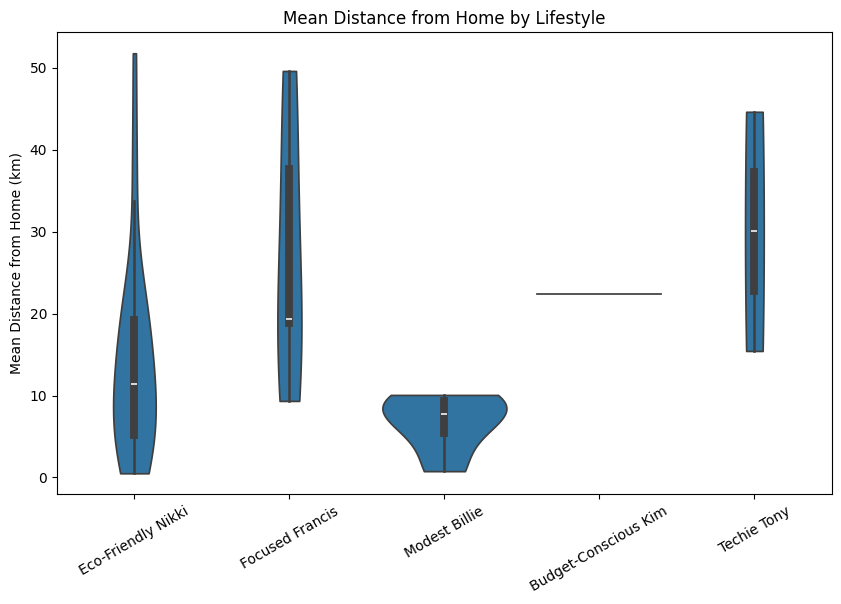

In [54]:
# Plot mean_home_m by lifestyle1 (violin plot)
home_dispersion = home_dispersion.merge(lifestyles[['participantid', 'lifestyle1']], left_on='participant_id', right_on='participantid', how='left').drop(columns=['participantid'])
home_dispersion["mean_home_km"] = home_dispersion["mean_home_m"] / 1000 # convert to km for better readability
plt.figure(figsize=(10,6))
sns.violinplot(data=home_dispersion, x="lifestyle1", y="mean_home_km", cut=0)
plt.title("Mean Distance from Home by Lifestyle")
plt.xlabel("")
plt.ylabel("Mean Distance from Home (km)")
plt.xticks(rotation=30)
plt.show()

In [55]:
# Kruskal-Wallis test to see if there are significant differences in mean distance from home between lifestyles
from scipy.stats import kruskal
groups = [group["mean_home_m"].dropna().to_numpy(float) for name, group in home_dispersion.groupby("lifestyle1")]
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis H-test: H={stat:.2f}, p={p:.4f}")

Kruskal-Wallis H-test: H=9.32, p=0.0537


In [56]:
steps.head()

,participant_id,day,steps
0,219935XE1,2024-08-28,4179
1,219935XE1,2024-08-28,3992
2,219935XE1,2024-08-29,5254
3,219935XE1,2024-08-29,3017
4,219935XE1,2024-08-30,5837


In [57]:
lifestyles.head()

,participantid,lifestyle1,lifestyle2
0,4L5S1E,Eco-Friendly Nikki,Modest Billie
1,9U7Q9K,Eco-Friendly Nikki,Comfort-Oriented Gaby
2,8G2B2C,Eco-Friendly Nikki,Modest Billie
3,6F10L1F,Eco-Friendly Nikki,Modest Billie
4,10F11M1A,Eco-Friendly Nikki,Techie Tony


In [58]:
# Same but with number of steps per day instead of distance

# Add lifestyle1 and lifestyle2 to steps
steps = steps.merge(lifestyles[['participantid', 'lifestyle1', 'lifestyle2']], left_on='participant_id', right_on='participantid', how='left')
steps.drop(columns=['participantid'], inplace=True)

In [59]:
# Remove steps with missing lifestyle1 or lifestyle2
steps = steps.dropna(subset=['lifestyle1', 'lifestyle2'])

# Add day_type to steps, checking if the day is weekend or weekday based on date
steps['day'] = pd.to_datetime(steps['day'], errors='coerce')
steps['dow'] = steps['day'].dt.day_of_week
steps['is_weekend'] = steps['dow'].isin([5,6])

steps.head()

,participant_id,day,steps,lifestyle1,lifestyle2,dow,is_weekend
10,4L5S1E,2024-08-28,3992,Eco-Friendly Nikki,Modest Billie,2,False
11,4L5S1E,2024-08-29,3017,Eco-Friendly Nikki,Modest Billie,3,False
12,4L5S1E,2024-08-30,0,Eco-Friendly Nikki,Modest Billie,4,False
13,4L5S1E,2024-08-31,0,Eco-Friendly Nikki,Modest Billie,5,True
14,4L5S1E,2024-09-01,0,Eco-Friendly Nikki,Modest Billie,6,True


In [60]:
# Remove data with 0 steps
#steps = steps[steps['steps'] > 0]

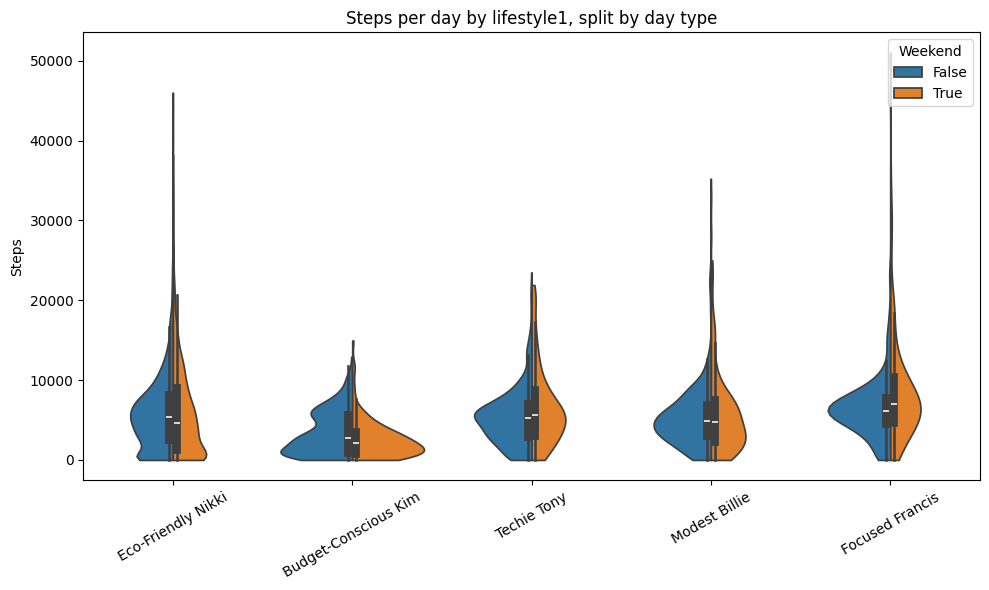

In [61]:
# Plot days per lifestyle1, split by day_type (weekend vs weekday) in a violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=steps,
    x="lifestyle1",
    y="steps",
    hue="is_weekend",
    split=True,
    cut=0
)

plt.title("Steps per day by lifestyle1, split by day type")
plt.xlabel("")
plt.ylabel("Steps")
plt.xticks(rotation=30)
plt.legend(title="Weekend", loc="upper right")
plt.tight_layout()
plt.show()

In [62]:
from scipy.stats import kruskal

# Aggregate to Participant level to avoid violating the independance assumption of the test (e.g., if we have 10 days of data for the same person, we should not treat them as 10 independent observations, but aggregate them to get one average value per person)
participant_steps = steps.groupby(['participant_id', 'lifestyle1'])['steps'].mean().reset_index()

# Perform Kruskal-Wallis test on the aggregated data
groups = [group["steps"].to_numpy(float) for name, group in participant_steps.groupby("lifestyle1")]
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis test statistic: {stat:.3f}, p-value: {p:.3f}")

if p >= 0.05:
    print("No significant difference in number of steps between lifestyles.")

Kruskal-Wallis test statistic: 2.829, p-value: 0.587
No significant difference in number of steps between lifestyles.


In [ ]:
# TODO: number of people that installed app, collected movements, collected lifestyle vs only people who do participate in lifestyle.>